In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "data/raw/yellow_tripdata_2025-01.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.shape

(3475226, 20)

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
passenger_count,540149,15.542845
congestion_surcharge,540149,15.542845
store_and_fwd_flag,540149,15.542845
RatecodeID,540149,15.542845
Airport_fee,540149,15.542845
tpep_dropoff_datetime,0,0.000000
VendorID,0,0.000000
tpep_pickup_datetime,0,0.000000
DOLocationID,0,0.000000
payment_type,0,0.000000


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Earliest pickup:", df["tpep_pickup_datetime"].min())
print("Latest pickup:", df["tpep_pickup_datetime"].max())

print(
    "Trips outside January 2025:",
    (~df["tpep_pickup_datetime"].between(
        "2025-01-01",
        "2025-01-31 23:59:59"
    )).sum()
)

Earliest pickup: 2024-12-31 20:47:55
Latest pickup: 2025-02-01 00:00:44
Trips outside January 2025: 22


In [10]:
# Data quality checks

quality_checks = {
    "Outside Jan 2025": (~df["tpep_pickup_datetime"].between(
        "2025-01-01", "2025-01-31 23:59:59"
    )).sum(),

    "Zero trip distance": (df["trip_distance"] == 0).sum(),

    "Negative trip distance": (df["trip_distance"] < 0).sum(),

    "Zero fare": (df["fare_amount"] == 0).sum(),

    "Negative fare": (df["fare_amount"] < 0).sum(),

    "Dropoff before pickup": (
        df["tpep_dropoff_datetime"] < df["tpep_pickup_datetime"]
    ).sum(),

    "Same pickup and dropoff time": (
        df["tpep_dropoff_datetime"] == df["tpep_pickup_datetime"]
    ).sum(),

    "Invalid pickup zone": (
        (df["PULocationID"] < 1) |
        (df["PULocationID"] > 265)
    ).sum()
}

pd.Series(quality_checks)

Outside Jan 2025                    22
Zero trip distance               90893
Negative trip distance               0
Zero fare                         1398
Negative fare                   144118
Dropoff before pickup              124
Same pickup and dropoff time      1927
Invalid pickup zone                  0
dtype: int64

In [11]:
# Create cleaned dataset for demand forecasting
df_clean = df[
    (df["tpep_pickup_datetime"] >= "2025-01-01") &
    (df["tpep_pickup_datetime"] < "2025-02-01") &
    (df["PULocationID"].between(1, 265))
].copy()

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 3475226
Clean rows: 3475204
Rows removed: 22


In [12]:
print("Start:", df_clean["tpep_pickup_datetime"].min())
print("End:", df_clean["tpep_pickup_datetime"].max())

print(
    "Invalid zones:",
    (~df_clean["PULocationID"].between(1, 265)).sum()
)

Start: 2025-01-01 00:00:00
End: 2025-01-31 23:59:59
Invalid zones: 0


In [13]:
df_clean["pickup_date"] = df_clean["tpep_pickup_datetime"].dt.date
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["day_of_week"] = df_clean["tpep_pickup_datetime"].dt.day_name()
df_clean["day"] = df_clean["tpep_pickup_datetime"].dt.day

In [14]:
df_clean[
    ["tpep_pickup_datetime", "pickup_date", "pickup_hour", "day_of_week"]
].head()

,tpep_pickup_datetime,pickup_date,pickup_hour,day_of_week
0,2025-01-01 00:18:38,2025-01-01,0,Wednesday
1,2025-01-01 00:32:40,2025-01-01,0,Wednesday
2,2025-01-01 00:44:04,2025-01-01,0,Wednesday
3,2025-01-01 00:14:27,2025-01-01,0,Wednesday
4,2025-01-01 00:21:34,2025-01-01,0,Wednesday


In [15]:
daily_demand = (
    df_clean
    .groupby("pickup_date")
    .size()
    .reset_index(name="trip_count")
)

daily_demand.head()

,pickup_date,trip_count
0,2025-01-01,90188
1,2025-01-02,84832
2,2025-01-03,91250
3,2025-01-04,97804
4,2025-01-05,79624


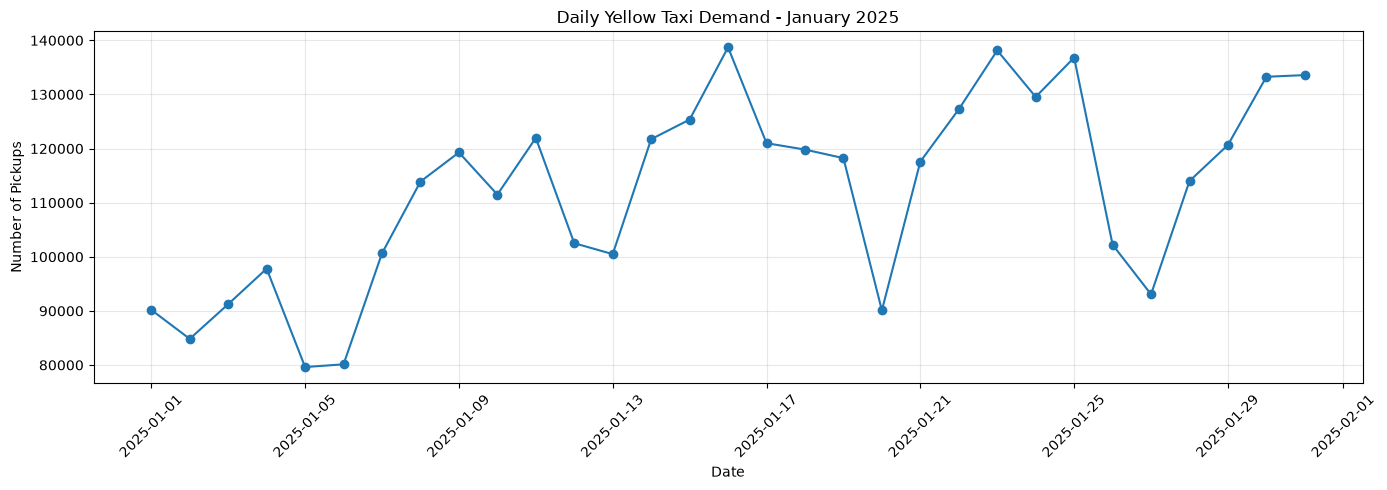

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["pickup_date"],
    daily_demand["trip_count"],
    marker="o"
)

plt.title("Daily Yellow Taxi Demand - January 2025")
plt.xlabel("Date")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
hourly_pattern = (
    df_clean
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

hourly_pattern

,pickup_hour,trip_count
0,0,93416
1,1,64484
2,2,43929
3,3,28492
4,4,20033
5,5,22551
6,6,50026
7,7,102581
8,8,141305
9,9,142877


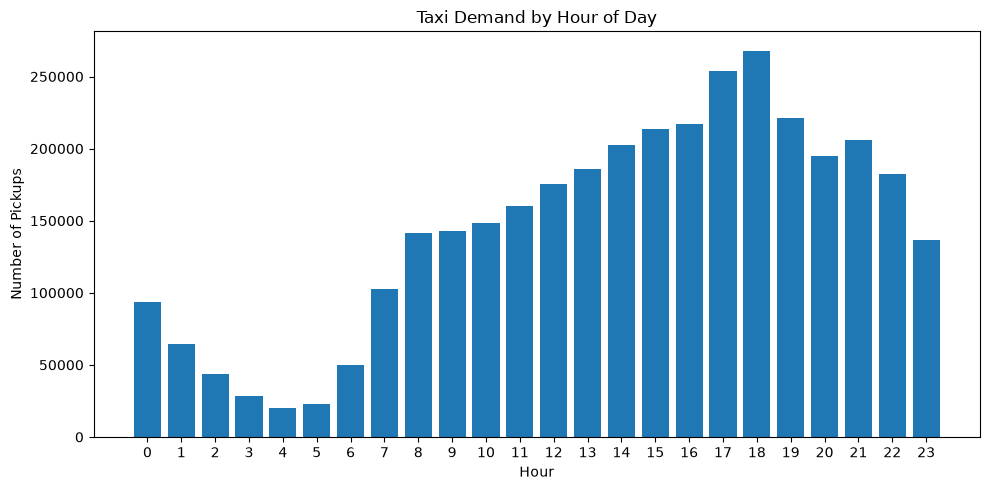

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_pattern["pickup_hour"],
    hourly_pattern["trip_count"]
)

plt.title("Taxi Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Pickups")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [19]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_demand = (
    df_clean
    .groupby("day_of_week")
    .size()
    .reindex(day_order)
)

weekday_demand

day_of_week
Monday       363772
Tuesday      453972
Wednesday    577375
Thursday     614230
Friday       586863
Saturday     476398
Sunday       402594
dtype: int64

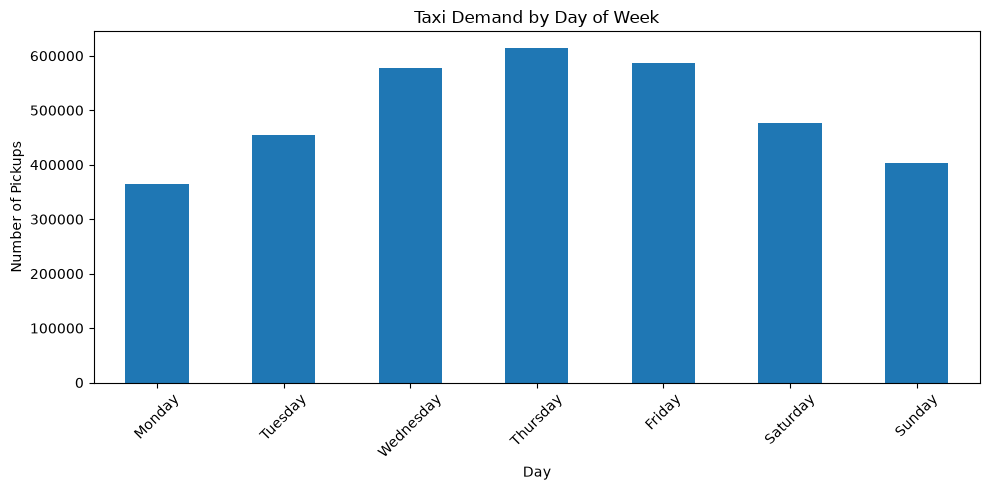

In [20]:
plt.figure(figsize=(10, 5))

weekday_demand.plot(kind="bar")

plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Daily demand with weekday information
daily_eda = (
    df_clean
    .groupby(["pickup_date", "day_of_week"])
    .size()
    .reset_index(name="trip_count")
)

avg_weekday_demand = (
    daily_eda
    .groupby("day_of_week")["trip_count"]
    .mean()
    .reindex(day_order)
)

avg_weekday_demand

day_of_week
Monday        90943.0
Tuesday      113493.0
Wednesday    115475.0
Thursday     122846.0
Friday       117372.6
Saturday     119099.5
Sunday       100648.5
Name: trip_count, dtype: float64

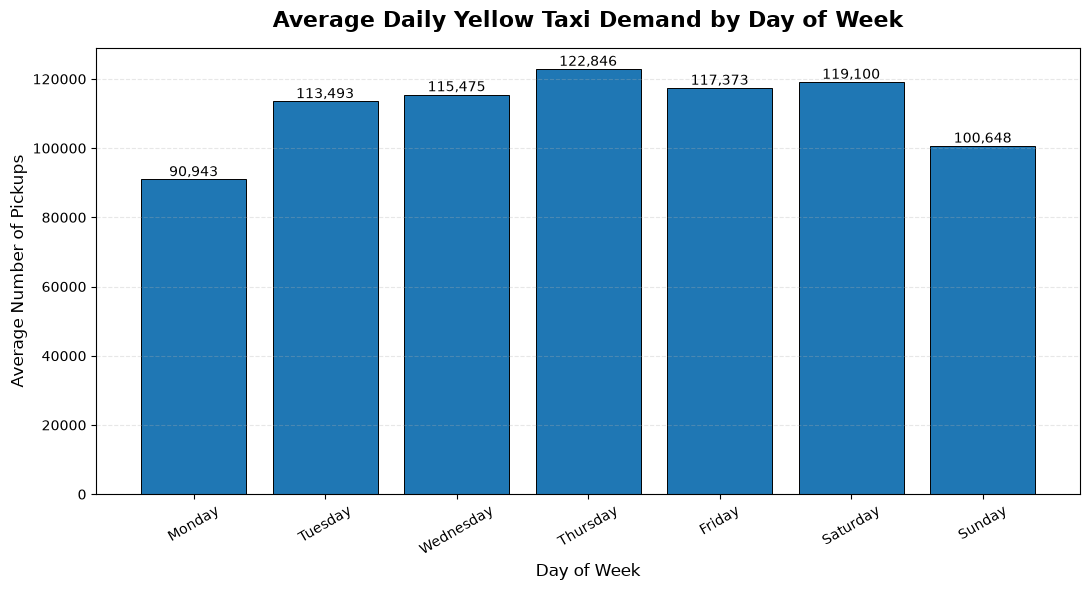

In [22]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    avg_weekday_demand.index,
    avg_weekday_demand.values,
    edgecolor="black",
    linewidth=0.7
)

plt.title(
    "Average Daily Yellow Taxi Demand by Day of Week",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Number of Pickups", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
zone_demand = (
    df_clean
    .groupby("PULocationID")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="trip_count")
)

zone_demand.head(15)

,PULocationID,trip_count
0,161,169977
1,237,163703
2,236,155647
3,132,146135
4,230,125829
5,186,119130
6,162,117930
7,142,110584
8,239,96614
9,163,95905


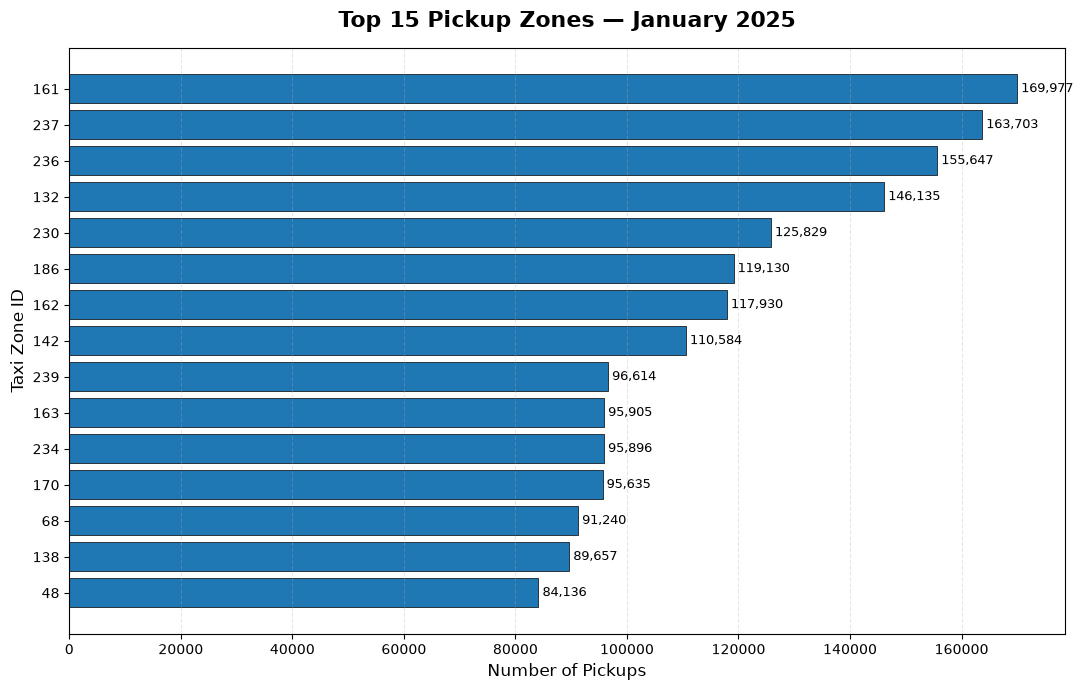

In [24]:
top_zones = zone_demand.head(15).sort_values("trip_count")

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_zones["PULocationID"].astype(str),
    top_zones["trip_count"],
    edgecolor="black",
    linewidth=0.5
)

plt.title(
    "Top 15 Pickup Zones — January 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Pickups", fontsize=12)
plt.ylabel("Taxi Zone ID", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f" {width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [25]:
zone_lookup = pd.read_csv("data/external/taxi_zone_lookup.csv")

print(zone_lookup.shape)
zone_lookup.head()

(265, 4)


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [26]:
zone_demand_named = zone_demand.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_demand_named[
    ["PULocationID", "Borough", "Zone", "trip_count"]
].head(15)

,PULocationID,Borough,Zone,trip_count
0,161,Manhattan,Midtown Center,169977
1,237,Manhattan,Upper East Side South,163703
2,236,Manhattan,Upper East Side North,155647
3,132,Queens,JFK Airport,146135
4,230,Manhattan,Times Sq/Theatre District,125829
5,186,Manhattan,Penn Station/Madison Sq West,119130
6,162,Manhattan,Midtown East,117930
7,142,Manhattan,Lincoln Square East,110584
8,239,Manhattan,Upper West Side South,96614
9,163,Manhattan,Midtown North,95905


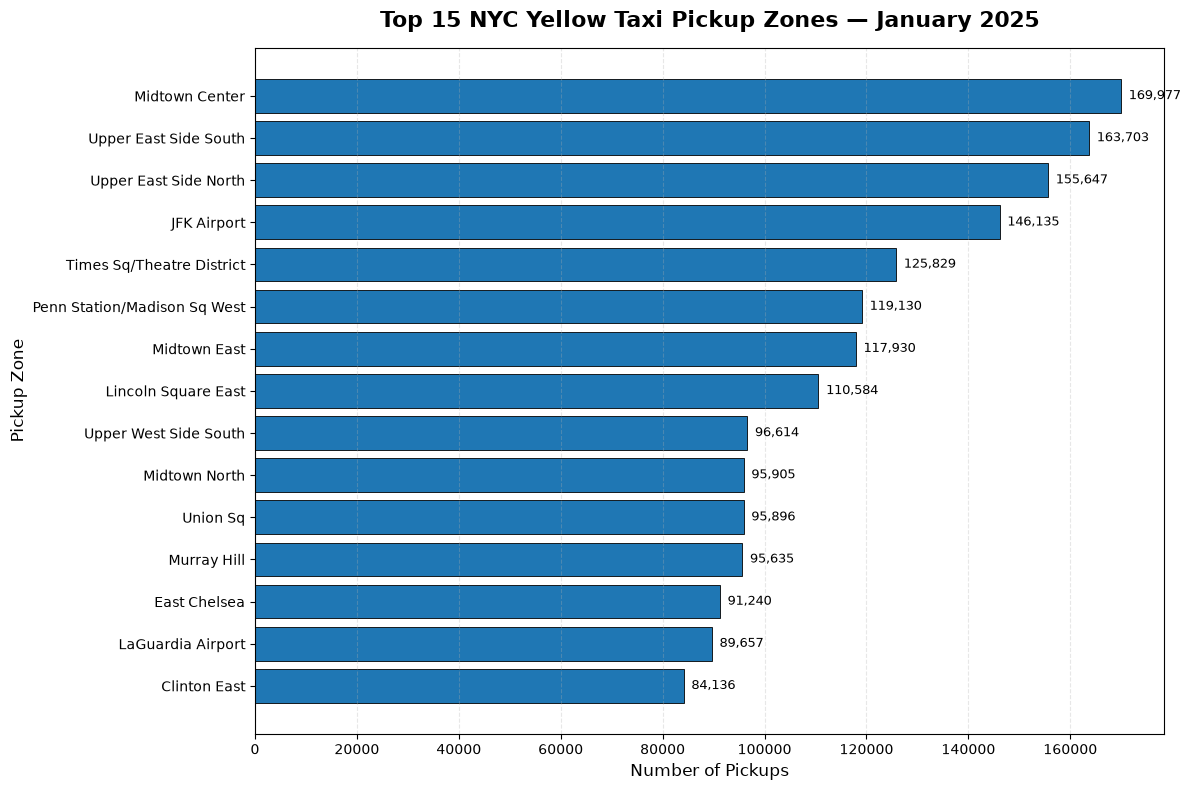

In [27]:
top_zones_named = (
    zone_demand_named
    .head(15)
    .sort_values("trip_count")
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_zones_named["Zone"],
    top_zones_named["trip_count"],
    edgecolor="black",
    linewidth=0.6
)

plt.title(
    "Top 15 NYC Yellow Taxi Pickup Zones — January 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Pickups", fontsize=12)
plt.ylabel("Pickup Zone", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1500,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [28]:
df_clean["pickup_hour_timestamp"] = (
    df_clean["tpep_pickup_datetime"]
    .dt.floor("h")
)

In [29]:
df_clean[
    [
        "tpep_pickup_datetime",
        "pickup_hour_timestamp",
        "PULocationID"
    ]
].head()

,tpep_pickup_datetime,pickup_hour_timestamp,PULocationID
0,2025-01-01 00:18:38,2025-01-01,229
1,2025-01-01 00:32:40,2025-01-01,236
2,2025-01-01 00:44:04,2025-01-01,141
3,2025-01-01 00:14:27,2025-01-01,244
4,2025-01-01 00:21:34,2025-01-01,244


In [30]:
hourly_zone_demand = (
    df_clean
    .groupby(
        ["pickup_hour_timestamp", "PULocationID"]
    )
    .size()
    .reset_index(name="demand")
)

print(hourly_zone_demand.shape)

hourly_zone_demand.head(10)

(97014, 3)


,pickup_hour_timestamp,PULocationID,demand
0,2025-01-01,4,28
1,2025-01-01,7,12
2,2025-01-01,9,1
3,2025-01-01,10,1
4,2025-01-01,12,1
5,2025-01-01,13,9
6,2025-01-01,14,4
7,2025-01-01,15,1
8,2025-01-01,16,1
9,2025-01-01,17,5


In [31]:
active_zones = sorted(df_clean["PULocationID"].unique())

print("Number of pickup zones observed:", len(active_zones))
print(active_zones)

Number of pickup zones observed: 261
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44), np.int32(45), np.int32(46), np.int32(47), np.int32(48), np.int32(49), np.int32(50), np.int32(51), np.int32(52), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(57), np.int32(58), np.int32(59), np.int32(60), np.int32(61), np.int32(62), np.int32(63), np.int32(64), np.int32(65), np.int32(66), np.int32(67), np.int32(68), np.int32(69), np.in

In [32]:
print("Number of zones in lookup table:", zone_lookup["LocationID"].nunique())

Number of zones in lookup table: 265


In [33]:
all_hours = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-01-31 23:00:00",
    freq="h"
)

print("Number of hours:", len(all_hours))

Number of hours: 744


In [34]:
full_grid = pd.MultiIndex.from_product(
    [all_hours, active_zones],
    names=["pickup_hour_timestamp", "PULocationID"]
).to_frame(index=False)

print("Full grid shape:", full_grid.shape)

full_grid.head()

Full grid shape: (194184, 2)


,pickup_hour_timestamp,PULocationID
0,2025-01-01,1
1,2025-01-01,2
2,2025-01-01,3
3,2025-01-01,4
4,2025-01-01,5


In [35]:
demand_df = full_grid.merge(
    hourly_zone_demand,
    on=["pickup_hour_timestamp", "PULocationID"],
    how="left"
)

demand_df["demand"] = (
    demand_df["demand"]
    .fillna(0)
    .astype("int32")
)

In [36]:
print("Final shape:", demand_df.shape)
print("Missing demand:", demand_df["demand"].isna().sum())
print("Zero-demand rows:", (demand_df["demand"] == 0).sum())

demand_df.head(10)

Final shape: (194184, 3)
Missing demand: 0
Zero-demand rows: 97170


,pickup_hour_timestamp,PULocationID,demand
0,2025-01-01,1,0
1,2025-01-01,2,0
2,2025-01-01,3,0
3,2025-01-01,4,28
4,2025-01-01,5,0
5,2025-01-01,6,0
6,2025-01-01,7,12
7,2025-01-01,8,0
8,2025-01-01,9,1
9,2025-01-01,10,1


In [37]:
print("Trips in cleaned data:", len(df_clean))
print("Trips represented in demand data:", demand_df["demand"].sum())

assert demand_df["demand"].sum() == len(df_clean)

print("Validation passed!")

Trips in cleaned data: 3475204
Trips represented in demand data: 3475204
Validation passed!


In [38]:
demand_df["demand"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

count    194184.000000
mean         17.896449
std          55.827342
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
90%          49.000000
95%         123.000000
99%         282.000000
99.9%       526.000000
max         950.000000
Name: demand, dtype: float64

In [39]:
demand_df.nlargest(10, "demand")

,pickup_hour_timestamp,PULocationID,demand
156939,2025-01-26 01:00:00,79,950
156678,2025-01-26 00:00:00,79,926
142662,2025-01-23 18:00:00,161,891
136398,2025-01-22 18:00:00,161,869
92550,2025-01-15 18:00:00,161,864
136920,2025-01-22 20:00:00,161,853
150414,2025-01-25 00:00:00,79,847
142923,2025-01-23 19:00:00,161,837
186510,2025-01-30 18:00:00,161,836
130134,2025-01-21 18:00:00,161,835


In [40]:
demand_df = demand_df.merge(
    zone_lookup[
        ["LocationID", "Borough", "Zone", "service_zone"]
    ],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

demand_df.drop(columns="LocationID", inplace=True)

demand_df.head()

,pickup_hour_timestamp,PULocationID,demand,Borough,Zone,service_zone
0,2025-01-01,1,0,EWR,Newark Airport,EWR
1,2025-01-01,2,0,Queens,Jamaica Bay,Boro Zone
2,2025-01-01,3,0,Bronx,Allerton/Pelham Gardens,Boro Zone
3,2025-01-01,4,28,Manhattan,Alphabet City,Yellow Zone
4,2025-01-01,5,0,Staten Island,Arden Heights,Boro Zone


In [41]:
print("Missing zone names:", demand_df["Zone"].isna().sum())
print("Final shape:", demand_df.shape)

Missing zone names: 744
Final shape: (194184, 6)


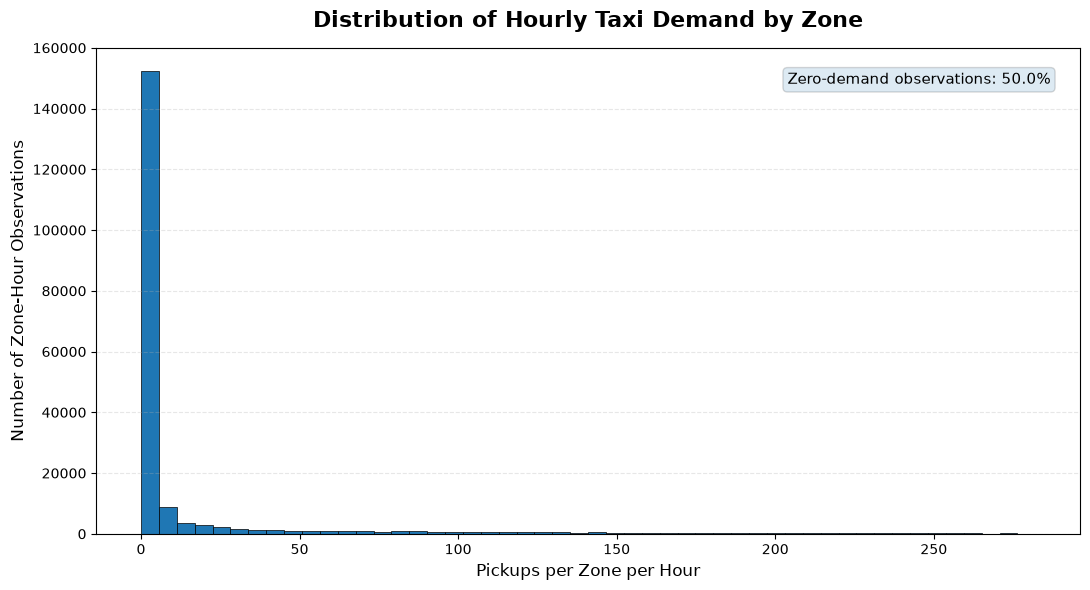

In [42]:
fig, ax = plt.subplots(figsize=(11, 6))

# Limit visualization to 99th percentile so extreme values
# don't compress the entire histogram
upper_limit = demand_df["demand"].quantile(0.99)

plot_data = demand_df.loc[
    demand_df["demand"] <= upper_limit,
    "demand"
]

ax.hist(
    plot_data,
    bins=50,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title(
    "Distribution of Hourly Taxi Demand by Zone",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Pickups per Zone per Hour", fontsize=12)
ax.set_ylabel("Number of Zone-Hour Observations", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.text(
    0.97,
    0.95,
    f"Zero-demand observations: {(demand_df['demand'] == 0).mean():.1%}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()

In [43]:
missing_zone_rows = demand_df[demand_df["Zone"].isna()]

print(
    missing_zone_rows["PULocationID"].unique()
)

print(
    missing_zone_rows["PULocationID"].value_counts()
)

[264]
PULocationID
264    744
Name: count, dtype: int64


In [44]:
missing_ids = set(active_zones) - set(zone_lookup["LocationID"])

print("Active IDs missing from lookup:", missing_ids)

Active IDs missing from lookup: set()


In [45]:
zone_lookup[zone_lookup["LocationID"] == 264]

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN


In [46]:
df_clean[df_clean["PULocationID"] == 264].shape

(8141, 25)

In [47]:
df_clean[df_clean["PULocationID"] == 264][
    ["tpep_pickup_datetime", "PULocationID"]
].head(10)

,tpep_pickup_datetime,PULocationID
128,2025-01-01 00:19:33,264
129,2025-01-01 00:32:34,264
130,2025-01-01 01:02:16,264
389,2025-01-01 00:52:29,264
565,2025-01-01 00:41:49,264
566,2025-01-01 00:59:53,264
2543,2025-01-01 00:29:02,264
3089,2025-01-01 00:27:37,264
3250,2025-01-01 00:31:53,264
3612,2025-01-01 00:47:01,264


In [48]:
demand_df["Zone"] = demand_df["Zone"].fillna("Unknown Zone")
demand_df["Borough"] = demand_df["Borough"].fillna("Unknown")
demand_df["service_zone"] = demand_df["service_zone"].fillna("Unknown")

print("Missing zone names:", demand_df["Zone"].isna().sum())

Missing zone names: 0


In [49]:
zone_lookup[
    zone_lookup["LocationID"].isin([79, 161])
]

,LocationID,Borough,Zone,service_zone
78,79,Manhattan,East Village,Yellow Zone
160,161,Manhattan,Midtown Center,Yellow Zone


In [50]:
demand_df[
    demand_df["PULocationID"].isin([79, 161])
].nlargest(15, "demand")[
    ["pickup_hour_timestamp", "PULocationID", "Zone", "Borough", "demand"]
]

,pickup_hour_timestamp,PULocationID,Zone,Borough,demand
156939,2025-01-26 01:00:00,79,East Village,Manhattan,950
156678,2025-01-26 00:00:00,79,East Village,Manhattan,926
142662,2025-01-23 18:00:00,161,Midtown Center,Manhattan,891
136398,2025-01-22 18:00:00,161,Midtown Center,Manhattan,869
92550,2025-01-15 18:00:00,161,Midtown Center,Manhattan,864
136920,2025-01-22 20:00:00,161,Midtown Center,Manhattan,853
150414,2025-01-25 00:00:00,79,East Village,Manhattan,847
142923,2025-01-23 19:00:00,161,Midtown Center,Manhattan,837
186510,2025-01-30 18:00:00,161,Midtown Center,Manhattan,836
130134,2025-01-21 18:00:00,161,Midtown Center,Manhattan,835


In [51]:
# ==========================================
# HISTORICAL WEATHER DATA
# ==========================================

import requests
import pandas as pd

In [52]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 40.7128,
    "longitude": -74.0060,
    "start_date": "2025-01-01",
    "end_date": "2025-01-31",
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "snowfall",
        "weather_code",
        "wind_speed_10m"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()

weather_json = response.json()

print("Weather data downloaded successfully!")

Weather data downloaded successfully!


In [53]:
weather_df = pd.DataFrame(
    weather_json["hourly"]
)

weather_df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2025-01-01T00:00,8.1,93,3.4,3.4,0.0,63,17.5
1,2025-01-01T01:00,9.1,95,0.9,0.9,0.0,53,12.4
2,2025-01-01T02:00,8.7,98,0.0,0.0,0.0,3,5.0
3,2025-01-01T03:00,8.9,99,0.0,0.0,0.0,3,8.3
4,2025-01-01T04:00,8.8,98,0.0,0.0,0.0,3,9.3


In [54]:
weather_df.shape

(744, 8)

In [55]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  744 non-null    str    
 1   temperature_2m        744 non-null    float64
 2   relative_humidity_2m  744 non-null    int64  
 3   precipitation         744 non-null    float64
 4   rain                  744 non-null    float64
 5   snowfall              744 non-null    float64
 6   weather_code          744 non-null    int64  
 7   wind_speed_10m        744 non-null    float64
dtypes: float64(5), int64(2), str(1)
memory usage: 58.3 KB


In [56]:
weather_df["time"] = pd.to_datetime(
    weather_df["time"]
)

weather_df.rename(
    columns={"time": "pickup_hour_timestamp"},
    inplace=True
)

In [57]:
print("Weather start:", weather_df["pickup_hour_timestamp"].min())
print("Weather end:", weather_df["pickup_hour_timestamp"].max())

weather_df.head()

Weather start: 2025-01-01 00:00:00
Weather end: 2025-01-31 23:00:00


,pickup_hour_timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2025-01-01 00:00:00,8.1,93,3.4,3.4,0.0,63,17.5
1,2025-01-01 01:00:00,9.1,95,0.9,0.9,0.0,53,12.4
2,2025-01-01 02:00:00,8.7,98,0.0,0.0,0.0,3,5.0
3,2025-01-01 03:00:00,8.9,99,0.0,0.0,0.0,3,8.3
4,2025-01-01 04:00:00,8.8,98,0.0,0.0,0.0,3,9.3


In [58]:
print("Weather rows:", len(weather_df))

print("\nMissing values:")
print(weather_df.isnull().sum())

print(
    "\nDuplicate timestamps:",
    weather_df["pickup_hour_timestamp"].duplicated().sum()
)

Weather rows: 744

Missing values:
pickup_hour_timestamp    0
temperature_2m           0
relative_humidity_2m     0
precipitation            0
rain                     0
snowfall                 0
weather_code             0
wind_speed_10m           0
dtype: int64

Duplicate timestamps: 0


In [59]:
WEATHER_PATH = "data/external/nyc_weather_2025_01.parquet"

weather_df.to_parquet(
    WEATHER_PATH,
    index=False
)

print("Weather data saved successfully!")

Weather data saved successfully!


In [60]:
print("Taxi timestamp dtype:",
      demand_df["pickup_hour_timestamp"].dtype)

print("Weather timestamp dtype:",
      weather_df["pickup_hour_timestamp"].dtype)

Taxi timestamp dtype: datetime64[us]
Weather timestamp dtype: datetime64[us]


In [61]:
print(demand_df.shape)
demand_df.head()

(194184, 6)


,pickup_hour_timestamp,PULocationID,demand,Borough,Zone,service_zone
0,2025-01-01,1,0,EWR,Newark Airport,EWR
1,2025-01-01,2,0,Queens,Jamaica Bay,Boro Zone
2,2025-01-01,3,0,Bronx,Allerton/Pelham Gardens,Boro Zone
3,2025-01-01,4,28,Manhattan,Alphabet City,Yellow Zone
4,2025-01-01,5,0,Staten Island,Arden Heights,Boro Zone


In [62]:
print(
    "Taxi timestamp dtype:",
    demand_df["pickup_hour_timestamp"].dtype
)

print(
    "Weather timestamp dtype:",
    weather_df["pickup_hour_timestamp"].dtype
)

Taxi timestamp dtype: datetime64[us]
Weather timestamp dtype: datetime64[us]


In [63]:
model_df = demand_df.merge(
    weather_df,
    on="pickup_hour_timestamp",
    how="left"
)

print("Before merge:", demand_df.shape)
print("After merge :", model_df.shape)

model_df.head()

Before merge: (194184, 6)
After merge : (194184, 13)


,pickup_hour_timestamp,PULocationID,demand,Borough,Zone,service_zone,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2025-01-01,1,0,EWR,Newark Airport,EWR,8.1,93,3.4,3.4,0.0,63,17.5
1,2025-01-01,2,0,Queens,Jamaica Bay,Boro Zone,8.1,93,3.4,3.4,0.0,63,17.5
2,2025-01-01,3,0,Bronx,Allerton/Pelham Gardens,Boro Zone,8.1,93,3.4,3.4,0.0,63,17.5
3,2025-01-01,4,28,Manhattan,Alphabet City,Yellow Zone,8.1,93,3.4,3.4,0.0,63,17.5
4,2025-01-01,5,0,Staten Island,Arden Heights,Boro Zone,8.1,93,3.4,3.4,0.0,63,17.5


In [64]:
weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weather_code",
    "wind_speed_10m"
]

print("Missing weather after merge:")
print(model_df[weather_columns].isnull().sum())

print("\nRows before merge:", len(demand_df))
print("Rows after merge :", len(model_df))

print("\nDemand before merge:", demand_df["demand"].sum())
print("Demand after merge :", model_df["demand"].sum())

Missing weather after merge:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weather_code            0
wind_speed_10m          0
dtype: int64

Rows before merge: 194184
Rows after merge : 194184

Demand before merge: 3475204
Demand after merge : 3475204


In [65]:
assert len(model_df) == len(demand_df), \
    "Merge changed number of rows!"

assert model_df[weather_columns].isnull().sum().sum() == 0, \
    "Some hours did not match weather!"

assert model_df["demand"].sum() == demand_df["demand"].sum(), \
    "Demand changed after merge!"

print("✅ All weather merge validation checks passed!")

✅ All weather merge validation checks passed!


In [66]:
model_df = model_df.sort_values(
    ["PULocationID", "pickup_hour_timestamp"]
).reset_index(drop=True)

model_df.head()

,pickup_hour_timestamp,PULocationID,demand,Borough,Zone,service_zone,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2025-01-01 00:00:00,1,0,EWR,Newark Airport,EWR,8.1,93,3.4,3.4,0.0,63,17.5
1,2025-01-01 01:00:00,1,0,EWR,Newark Airport,EWR,9.1,95,0.9,0.9,0.0,53,12.4
2,2025-01-01 02:00:00,1,0,EWR,Newark Airport,EWR,8.7,98,0.0,0.0,0.0,3,5.0
3,2025-01-01 03:00:00,1,0,EWR,Newark Airport,EWR,8.9,99,0.0,0.0,0.0,3,8.3
4,2025-01-01 04:00:00,1,0,EWR,Newark Airport,EWR,8.8,98,0.0,0.0,0.0,3,9.3


In [67]:
model_df["hour"] = model_df["pickup_hour_timestamp"].dt.hour
model_df["day_of_week"] = model_df["pickup_hour_timestamp"].dt.dayofweek
model_df["day_of_month"] = model_df["pickup_hour_timestamp"].dt.day
model_df["month"] = model_df["pickup_hour_timestamp"].dt.month

model_df["is_weekend"] = (
    model_df["day_of_week"] >= 5
).astype("int8")

In [68]:
model_df[[
    "pickup_hour_timestamp",
    "PULocationID",
    "demand",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend"
]].head(30)

,pickup_hour_timestamp,PULocationID,demand,hour,day_of_week,day_of_month,month,is_weekend
0,2025-01-01 00:00:00,1,0,0,2,1,1,0
1,2025-01-01 01:00:00,1,0,1,2,1,1,0
2,2025-01-01 02:00:00,1,0,2,2,1,1,0
3,2025-01-01 03:00:00,1,0,3,2,1,1,0
4,2025-01-01 04:00:00,1,0,4,2,1,1,0
5,2025-01-01 05:00:00,1,0,5,2,1,1,0
6,2025-01-01 06:00:00,1,1,6,2,1,1,0
7,2025-01-01 07:00:00,1,0,7,2,1,1,0
8,2025-01-01 08:00:00,1,0,8,2,1,1,0
9,2025-01-01 09:00:00,1,4,9,2,1,1,0


In [69]:
import numpy as np

# Hour: 24-hour cycle
model_df["hour_sin"] = np.sin(
    2 * np.pi * model_df["hour"] / 24
)

model_df["hour_cos"] = np.cos(
    2 * np.pi * model_df["hour"] / 24
)

# Day of week: 7-day cycle
model_df["dow_sin"] = np.sin(
    2 * np.pi * model_df["day_of_week"] / 7
)

model_df["dow_cos"] = np.cos(
    2 * np.pi * model_df["day_of_week"] / 7
)

In [70]:
model_df[[
    "pickup_hour_timestamp",
    "hour",
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "dow_sin",
    "dow_cos"
]].head(25)

,pickup_hour_timestamp,hour,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos
0,2025-01-01 00:00:00,0,0.000000e+00,1.000000e+00,2,0.974928,-0.222521
1,2025-01-01 01:00:00,1,2.588190e-01,9.659258e-01,2,0.974928,-0.222521
2,2025-01-01 02:00:00,2,5.000000e-01,8.660254e-01,2,0.974928,-0.222521
3,2025-01-01 03:00:00,3,7.071068e-01,7.071068e-01,2,0.974928,-0.222521
4,2025-01-01 04:00:00,4,8.660254e-01,5.000000e-01,2,0.974928,-0.222521
5,2025-01-01 05:00:00,5,9.659258e-01,2.588190e-01,2,0.974928,-0.222521
6,2025-01-01 06:00:00,6,1.000000e+00,6.123234e-17,2,0.974928,-0.222521
7,2025-01-01 07:00:00,7,9.659258e-01,-2.588190e-01,2,0.974928,-0.222521
8,2025-01-01 08:00:00,8,8.660254e-01,-5.000000e-01,2,0.974928,-0.222521
9,2025-01-01 09:00:00,9,7.071068e-01,-7.071068e-01,2,0.974928,-0.222521


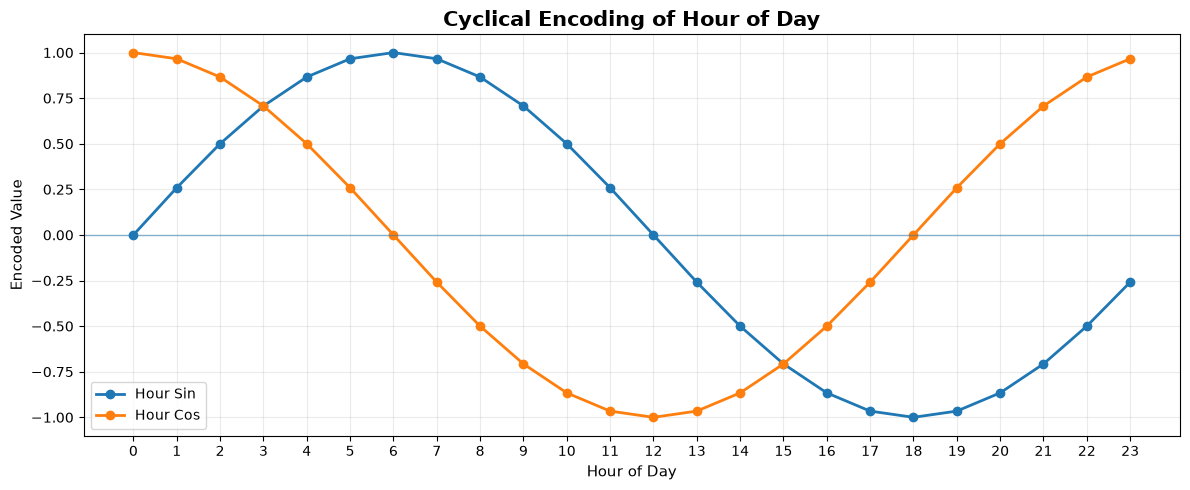

In [71]:
import matplotlib.pyplot as plt

hour_encoding = (
    model_df[
        ["hour", "hour_sin", "hour_cos"]
    ]
    .drop_duplicates()
    .sort_values("hour")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hour_encoding["hour"],
    hour_encoding["hour_sin"],
    marker="o",
    linewidth=2,
    label="Hour Sin"
)

ax.plot(
    hour_encoding["hour"],
    hour_encoding["hour_cos"],
    marker="o",
    linewidth=2,
    label="Hour Cos"
)

ax.axhline(0, linewidth=1, alpha=0.5)

ax.set_title(
    "Cyclical Encoding of Hour of Day",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Encoded Value", fontsize=11)

ax.set_xticks(range(24))
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [72]:
model_df["lag_1h"] = (
    model_df.groupby("PULocationID")["demand"]
    .shift(1)
)

model_df["lag_24h"] = (
    model_df.groupby("PULocationID")["demand"]
    .shift(24)
)

model_df["lag_168h"] = (
    model_df.groupby("PULocationID")["demand"]
    .shift(168)
)

In [73]:
model_df[
    model_df["PULocationID"] == 79
][[
    "pickup_hour_timestamp",
    "demand",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]].head(175)

,pickup_hour_timestamp,demand,lag_1h,lag_24h,lag_168h
58032,2025-01-01 00:00:00,353,NaN,NaN,NaN
58033,2025-01-01 01:00:00,474,353.0,NaN,NaN
58034,2025-01-01 02:00:00,492,474.0,NaN,NaN
58035,2025-01-01 03:00:00,447,492.0,NaN,NaN
58036,2025-01-01 04:00:00,207,447.0,NaN,NaN
...,...,...,...,...,...
58202,2025-01-08 02:00:00,12,17.0,11.0,492.0
58203,2025-01-08 03:00:00,10,12.0,3.0,447.0
58204,2025-01-08 04:00:00,3,10.0,6.0,207.0
58205,2025-01-08 05:00:00,9,3.0,8.0,80.0


In [74]:
zone79 = model_df[
    model_df["PULocationID"] == 79
].reset_index(drop=True)

zone79.loc[168:172, [
    "pickup_hour_timestamp",
    "demand",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]]

,pickup_hour_timestamp,demand,lag_1h,lag_24h,lag_168h
168,2025-01-08 00:00:00,42,93.0,31.0,353.0
169,2025-01-08 01:00:00,17,42.0,16.0,474.0
170,2025-01-08 02:00:00,12,17.0,11.0,492.0
171,2025-01-08 03:00:00,10,12.0,3.0,447.0
172,2025-01-08 04:00:00,3,10.0,6.0,207.0


In [75]:
print("Current:")
print(
    zone79.loc[168,
    ["pickup_hour_timestamp", "demand",
     "lag_1h", "lag_24h", "lag_168h"]]
)

print("\n1 hour earlier demand:")
print(zone79.loc[167, "demand"])

print("\n24 hours earlier demand:")
print(zone79.loc[144, "demand"])

print("\n168 hours earlier demand:")
print(zone79.loc[0, "demand"])

Current:
pickup_hour_timestamp    2025-01-08 00:00:00
demand                                    42
lag_1h                                  93.0
lag_24h                                 31.0
lag_168h                               353.0
Name: 168, dtype: object

1 hour earlier demand:
93

24 hours earlier demand:
31

168 hours earlier demand:
353


In [76]:
model_df["rolling_mean_3h"] = (
    model_df.groupby("PULocationID")["demand"]
    .transform(
        lambda x: x.shift(1).rolling(window=3).mean()
    )
)

model_df["rolling_mean_24h"] = (
    model_df.groupby("PULocationID")["demand"]
    .transform(
        lambda x: x.shift(1).rolling(window=24).mean()
    )
)

model_df["rolling_std_24h"] = (
    model_df.groupby("PULocationID")["demand"]
    .transform(
        lambda x: x.shift(1).rolling(window=24).std()
    )
)

In [77]:
zone79 = model_df[
    model_df["PULocationID"] == 79
].reset_index(drop=True)

zone79.loc[24:30, [
    "pickup_hour_timestamp",
    "demand",
    "lag_1h",
    "rolling_mean_3h",
    "rolling_mean_24h",
    "rolling_std_24h"
]]

,pickup_hour_timestamp,demand,lag_1h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h
24,2025-01-02 00:00:00,32,45.0,66.000000,130.208333,148.490954
25,2025-01-02 01:00:00,11,32.0,49.333333,116.833333,141.859596
26,2025-01-02 02:00:00,10,11.0,29.333333,97.541667,121.145970
27,2025-01-02 03:00:00,5,10.0,17.666667,77.458333,88.450910
28,2025-01-02 04:00:00,5,5.0,8.666667,59.041667,41.958032
29,2025-01-02 05:00:00,4,5.0,6.666667,50.625000,29.355116
30,2025-01-02 06:00:00,15,4.0,4.666667,47.458333,30.137337


In [78]:
print("Previous 3 demands:")
print(zone79.loc[21:23, "demand"].values)

print("\nManual 3-hour mean:")
print(zone79.loc[21:23, "demand"].mean())

print("\nFeature value:")
print(zone79.loc[24, "rolling_mean_3h"])

Previous 3 demands:
[82 71 45]

Manual 3-hour mean:
66.0

Feature value:
66.0


In [79]:
print("Manual previous 24-hour mean:")
print(zone79.loc[0:23, "demand"].mean())

print("\nFeature rolling mean:")
print(zone79.loc[24, "rolling_mean_24h"])

Manual previous 24-hour mean:
130.20833333333334

Feature rolling mean:
130.20833333333334


In [80]:
history_features = [
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_mean_24h",
    "rolling_std_24h"
]

model_df[history_features].isnull().sum()

lag_1h                261
lag_24h              6264
lag_168h            43848
rolling_mean_3h       783
rolling_mean_24h     6264
rolling_std_24h      6264
dtype: int64

In [81]:
ml_df = model_df.dropna(
    subset=history_features
).copy()

print("Full dataset :", model_df.shape)
print("Model dataset:", ml_df.shape)

print(
    "Rows removed:",
    len(model_df) - len(ml_df)
)

Full dataset : (194184, 28)
Model dataset: (150336, 28)
Rows removed: 43848


In [82]:
print(
    "Model start:",
    ml_df["pickup_hour_timestamp"].min()
)

print(
    "Model end:",
    ml_df["pickup_hour_timestamp"].max()
)

print(
    "Remaining missing historical values:",
    ml_df[history_features].isnull().sum().sum()
)

Model start: 2025-01-08 00:00:00
Model end: 2025-01-31 23:00:00
Remaining missing historical values: 0


In [83]:
model_df.to_parquet(
    "data/processed/taxi_demand_features_2025_01.parquet",
    index=False
)

print("Feature dataset saved successfully!")

Feature dataset saved successfully!


In [84]:
train_df = ml_df[
    ml_df["pickup_hour_timestamp"] < "2025-01-24"
].copy()

val_df = ml_df[
    (ml_df["pickup_hour_timestamp"] >= "2025-01-24") &
    (ml_df["pickup_hour_timestamp"] < "2025-01-28")
].copy()

test_df = ml_df[
    ml_df["pickup_hour_timestamp"] >= "2025-01-28"
].copy()

In [85]:
print("TRAIN")
print(train_df["pickup_hour_timestamp"].min())
print(train_df["pickup_hour_timestamp"].max())
print("Rows:", len(train_df))

print("\nVALIDATION")
print(val_df["pickup_hour_timestamp"].min())
print(val_df["pickup_hour_timestamp"].max())
print("Rows:", len(val_df))

print("\nTEST")
print(test_df["pickup_hour_timestamp"].min())
print(test_df["pickup_hour_timestamp"].max())
print("Rows:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))
print("Expected:", len(ml_df))

TRAIN
2025-01-08 00:00:00
2025-01-23 23:00:00
Rows: 100224

VALIDATION
2025-01-24 00:00:00
2025-01-27 23:00:00
Rows: 25056

TEST
2025-01-28 00:00:00
2025-01-31 23:00:00
Rows: 25056

Total: 150336
Expected: 150336


In [86]:
assert len(train_df) + len(val_df) + len(test_df) == len(ml_df)

assert train_df["pickup_hour_timestamp"].max() < \
       val_df["pickup_hour_timestamp"].min()

assert val_df["pickup_hour_timestamp"].max() < \
       test_df["pickup_hour_timestamp"].min()

print("✅ Temporal split validation passed!")

✅ Temporal split validation passed!


In [87]:
feature_columns = [
    # Location
    "PULocationID",

    # Time
    "hour",
    "day_of_week",
    "day_of_month",
    "is_weekend",

    # Cyclical time
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # Weather
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weather_code",
    "wind_speed_10m",

    # Historical demand
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_mean_24h",
    "rolling_std_24h"
]

target_column = "demand"

In [88]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

In [89]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (100224, 22)
y_train: (100224,)
X_val  : (25056, 22)
y_val  : (25056,)
X_test : (25056, 22)
y_test : (25056,)


In [90]:
print("Missing X_train:", X_train.isnull().sum().sum())
print("Missing X_val  :", X_val.isnull().sum().sum())
print("Missing X_test :", X_test.isnull().sum().sum())

Missing X_train: 0
Missing X_val  : 0
Missing X_test : 0


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_pred = val_df["lag_24h"]

baseline_mae = mean_absolute_error(
    y_val,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_val, baseline_pred)
)

baseline_r2 = r2_score(
    y_val,
    baseline_pred
)

print(f"Baseline MAE : {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R²  : {baseline_r2:.3f}")

Baseline MAE : 8.317
Baseline RMSE: 32.660
Baseline R²  : 0.668


In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

start = time.time()

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

training_time = time.time() - start

lr_mae = mean_absolute_error(y_val, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
lr_r2 = r2_score(y_val, lr_pred)

print(f"Linear Regression MAE : {lr_mae:.3f}")
print(f"Linear Regression RMSE: {lr_rmse:.3f}")
print(f"Linear Regression R²  : {lr_r2:.3f}")
print(f"Training + prediction : {training_time:.2f} seconds")

Linear Regression MAE : 5.019
Linear Regression RMSE: 14.973
Linear Regression R²  : 0.930
Training + prediction : 0.15 seconds


In [102]:
from sklearn.linear_model import Ridge
import time

start = time.time()

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_val)

ridge_time = time.time() - start

ridge_mae = mean_absolute_error(y_val, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
ridge_r2 = r2_score(y_val, ridge_pred)

print(f"Ridge MAE : {ridge_mae:.3f}")
print(f"Ridge RMSE: {ridge_rmse:.3f}")
print(f"Ridge R²  : {ridge_r2:.3f}")
print(f"Training + prediction: {ridge_time:.2f} seconds")

Ridge MAE : 5.019
Ridge RMSE: 14.973
Ridge R²  : 0.930
Training + prediction: 0.11 seconds


In [103]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor

poisson_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", PoissonRegressor(
        alpha=0.1,
        max_iter=500
    ))
])

start = time.time()

poisson_model.fit(X_train, y_train)

poisson_pred = poisson_model.predict(X_val)

poisson_time = time.time() - start

poisson_mae = mean_absolute_error(y_val, poisson_pred)
poisson_rmse = np.sqrt(
    mean_squared_error(y_val, poisson_pred)
)
poisson_r2 = r2_score(y_val, poisson_pred)

print(f"Poisson MAE : {poisson_mae:.3f}")
print(f"Poisson RMSE: {poisson_rmse:.3f}")
print(f"Poisson R²  : {poisson_r2:.3f}")
print(f"Training + prediction: {poisson_time:.2f} seconds")

Poisson MAE : 15.403
Poisson RMSE: 49.790
Poisson R²  : 0.228
Training + prediction: 0.99 seconds


In [104]:
from sklearn.ensemble import RandomForestRegressor
import time

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

start = time.time()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_time = time.time() - start

rf_mae = mean_absolute_error(y_val, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_val, rf_pred)
)

rf_r2 = r2_score(y_val, rf_pred)

print(f"Random Forest MAE : {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²  : {rf_r2:.3f}")
print(f"Training + prediction: {rf_time:.2f} seconds")

Random Forest MAE : 4.449
Random Forest RMSE: 14.564
Random Forest R²  : 0.934
Training + prediction: 21.10 seconds


In [105]:
from sklearn.ensemble import ExtraTreesRegressor

extra_model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

start = time.time()

extra_model.fit(X_train, y_train)
extra_pred = extra_model.predict(X_val)

extra_time = time.time() - start

extra_mae = mean_absolute_error(y_val, extra_pred)
extra_rmse = np.sqrt(
    mean_squared_error(y_val, extra_pred)
)
extra_r2 = r2_score(y_val, extra_pred)

print(f"Extra Trees MAE : {extra_mae:.3f}")
print(f"Extra Trees RMSE: {extra_rmse:.3f}")
print(f"Extra Trees R²  : {extra_r2:.3f}")
print(f"Training + prediction: {extra_time:.2f} seconds")

Extra Trees MAE : 4.125
Extra Trees RMSE: 13.235
Extra Trees R²  : 0.945
Training + prediction: 13.25 seconds


In [106]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

start = time.time()

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_val)

gb_time = time.time() - start

gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))
gb_r2 = r2_score(y_val, gb_pred)

print(f"Gradient Boosting MAE : {gb_mae:.3f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.3f}")
print(f"Gradient Boosting R²  : {gb_r2:.3f}")
print(f"Training + prediction: {gb_time:.2f} seconds")

Gradient Boosting MAE : 4.553
Gradient Boosting RMSE: 14.229
Gradient Boosting R²  : 0.937
Training + prediction: 56.52 seconds


In [107]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

start = time.time()

hist_model.fit(X_train, y_train)
hist_pred = hist_model.predict(X_val)

hist_time = time.time() - start

hist_mae = mean_absolute_error(y_val, hist_pred)
hist_rmse = np.sqrt(mean_squared_error(y_val, hist_pred))
hist_r2 = r2_score(y_val, hist_pred)

print(f"HistGradientBoosting MAE : {hist_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hist_rmse:.3f}")
print(f"HistGradientBoosting R²  : {hist_r2:.3f}")
print(f"Training + prediction: {hist_time:.2f} seconds")

HistGradientBoosting MAE : 4.495
HistGradientBoosting RMSE: 14.383
HistGradientBoosting R²  : 0.936
Training + prediction: 3.05 seconds


In [108]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

start = time.time()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

xgb_time = time.time() - start

xgb_mae = mean_absolute_error(y_val, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_val, xgb_pred)
)

xgb_r2 = r2_score(y_val, xgb_pred)

print(f"XGBoost MAE : {xgb_mae:.3f}")
print(f"XGBoost RMSE: {xgb_rmse:.3f}")
print(f"XGBoost R²  : {xgb_r2:.3f}")
print(f"Training + prediction: {xgb_time:.2f} seconds")

XGBoost MAE : 4.274
XGBoost RMSE: 13.504
XGBoost R²  : 0.943
Training + prediction: 3.48 seconds


In [109]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_val)

lgbm_time = time.time() - start

lgbm_mae = mean_absolute_error(y_val, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_val, lgbm_pred))
lgbm_r2 = r2_score(y_val, lgbm_pred)

print(f"LightGBM MAE : {lgbm_mae:.3f}")
print(f"LightGBM RMSE: {lgbm_rmse:.3f}")
print(f"LightGBM R²  : {lgbm_r2:.3f}")
print(f"Training + prediction: {lgbm_time:.2f} seconds")

LightGBM MAE : 4.371
LightGBM RMSE: 13.711
LightGBM R²  : 0.941
Training + prediction: 2.24 seconds


In [110]:
results_df = pd.DataFrame({
    "Model": [
        "Naive 24h",
        "Linear Regression",
        "Ridge",
        "Poisson",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        8.317,
        5.019,
        5.019,
        15.403,
        4.449,
        4.125,
        4.553,
        4.495,
        4.274,
        4.371
    ],
    "RMSE": [
        32.660,
        14.973,
        14.973,
        49.790,
        14.564,
        13.235,
        14.229,
        14.383,
        13.504,
        13.711
    ],
    "R2": [
        0.668,
        0.930,
        0.930,
        0.228,
        0.934,
        0.945,
        0.937,
        0.936,
        0.943,
        0.941
    ]
})

results_df.sort_values("MAE")

,Model,MAE,RMSE,R2
5,Extra Trees,4.125,13.235,0.945
8,XGBoost,4.274,13.504,0.943
9,LightGBM,4.371,13.711,0.941
4,Random Forest,4.449,14.564,0.934
7,HistGradientBoosting,4.495,14.383,0.936
6,Gradient Boosting,4.553,14.229,0.937
2,Ridge,5.019,14.973,0.930
1,Linear Regression,5.019,14.973,0.930
0,Naive 24h,8.317,32.660,0.668
3,Poisson,15.403,49.790,0.228


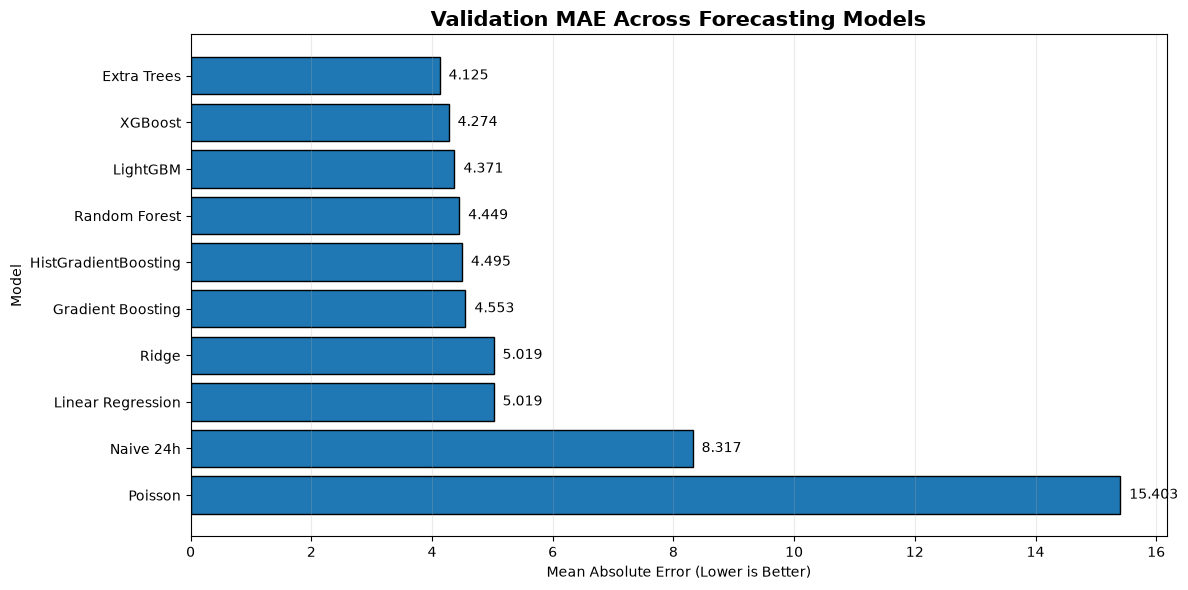

In [111]:
plot_df = results_df.sort_values("MAE")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    plot_df["Model"],
    plot_df["MAE"],
    edgecolor="black"
)

ax.set_title(
    "Validation MAE Across Forecasting Models",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mean Absolute Error (Lower is Better)")
ax.set_ylabel("Model")

ax.grid(
    axis="x",
    alpha=0.25
)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [112]:
results_df.to_csv(
    "artifacts/model_validation_results.csv",
    index=False
)

print("Model results saved!")

Model results saved!


In [113]:
zone161 = (
    model_df[
        model_df["PULocationID"] == 161
    ][["pickup_hour_timestamp", "demand"]]
    .copy()
    .sort_values("pickup_hour_timestamp")
    .reset_index(drop=True)
)

print(zone161.shape)
print(zone161["pickup_hour_timestamp"].min())
print(zone161["pickup_hour_timestamp"].max())

zone161.head()

(744, 2)
2025-01-01 00:00:00
2025-01-31 23:00:00


,pickup_hour_timestamp,demand
0,2025-01-01 00:00:00,274
1,2025-01-01 01:00:00,248
2,2025-01-01 02:00:00,150
3,2025-01-01 03:00:00,67
4,2025-01-01 04:00:00,33


In [114]:
zone161 = zone161.set_index("pickup_hour_timestamp")

zone161 = zone161.asfreq("h")

print("Missing demand:", zone161["demand"].isnull().sum())

zone161.head()

Missing demand: 0


,demand
pickup_hour_timestamp,
2025-01-01 00:00:00,274
2025-01-01 01:00:00,248
2025-01-01 02:00:00,150
2025-01-01 03:00:00,67
2025-01-01 04:00:00,33


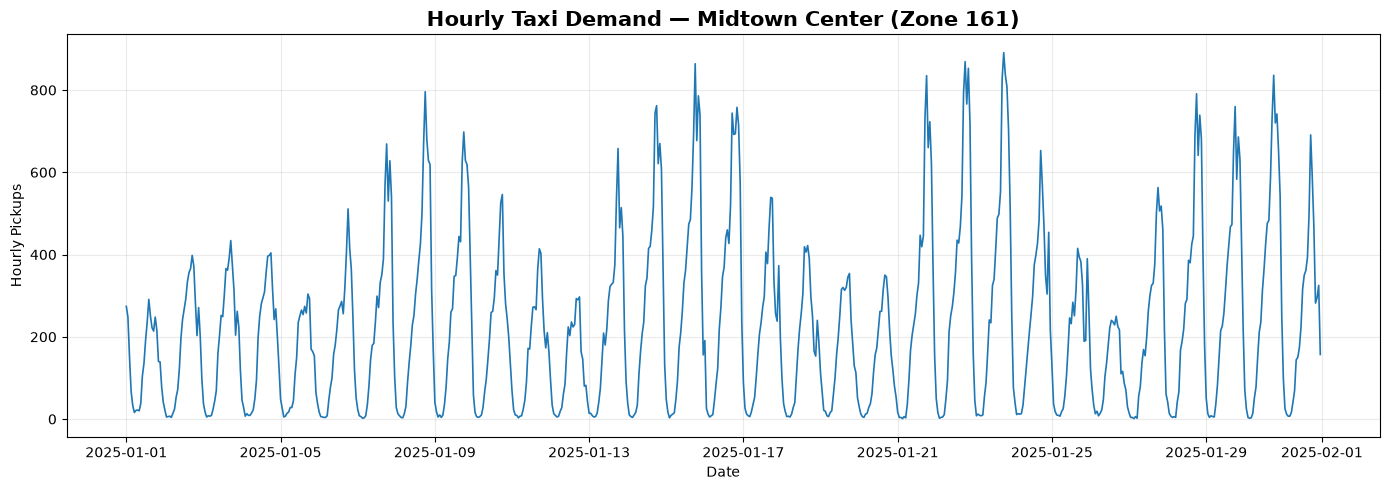

In [115]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    zone161.index,
    zone161["demand"],
    linewidth=1.2
)

ax.set_title(
    "Hourly Taxi Demand — Midtown Center (Zone 161)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Pickups")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [116]:
sarima_train = zone161[
    zone161.index < "2025-01-24"
].copy()

sarima_val = zone161[
    (zone161.index >= "2025-01-24") &
    (zone161.index < "2025-01-28")
].copy()

print("Train:", sarima_train.shape)
print("Validation:", sarima_val.shape)

print(
    sarima_train.index.min(),
    "→",
    sarima_train.index.max()
)

print(
    sarima_val.index.min(),
    "→",
    sarima_val.index.max()
)

Train: (552, 1)
Validation: (96, 1)
2025-01-01 00:00:00 → 2025-01-23 23:00:00
2025-01-24 00:00:00 → 2025-01-27 23:00:00


In [117]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

start = time.time()

sarima_model = SARIMAX(
    sarima_train["demand"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=100
)

sarima_time = time.time() - start

print(f"SARIMA training time: {sarima_time:.2f} seconds")

SARIMA training time: 5.35 seconds


In [118]:
sarima_pred = sarima_fit.forecast(
    steps=len(sarima_val)
)

sarima_pred.head()

2025-01-24 00:00:00    132.163152
2025-01-24 01:00:00     81.544322
2025-01-24 02:00:00     65.790164
2025-01-24 03:00:00     55.315613
2025-01-24 04:00:00     47.236867
Freq: h, Name: predicted_mean, dtype: float64

In [119]:
sarima_mae = mean_absolute_error(
    sarima_val["demand"],
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        sarima_val["demand"],
        sarima_pred
    )
)

sarima_r2 = r2_score(
    sarima_val["demand"],
    sarima_pred
)

print(f"SARIMA MAE : {sarima_mae:.3f}")
print(f"SARIMA RMSE: {sarima_rmse:.3f}")
print(f"SARIMA R²  : {sarima_r2:.3f}")

SARIMA MAE : 78.304
SARIMA RMSE: 119.035
SARIMA R²  : 0.480


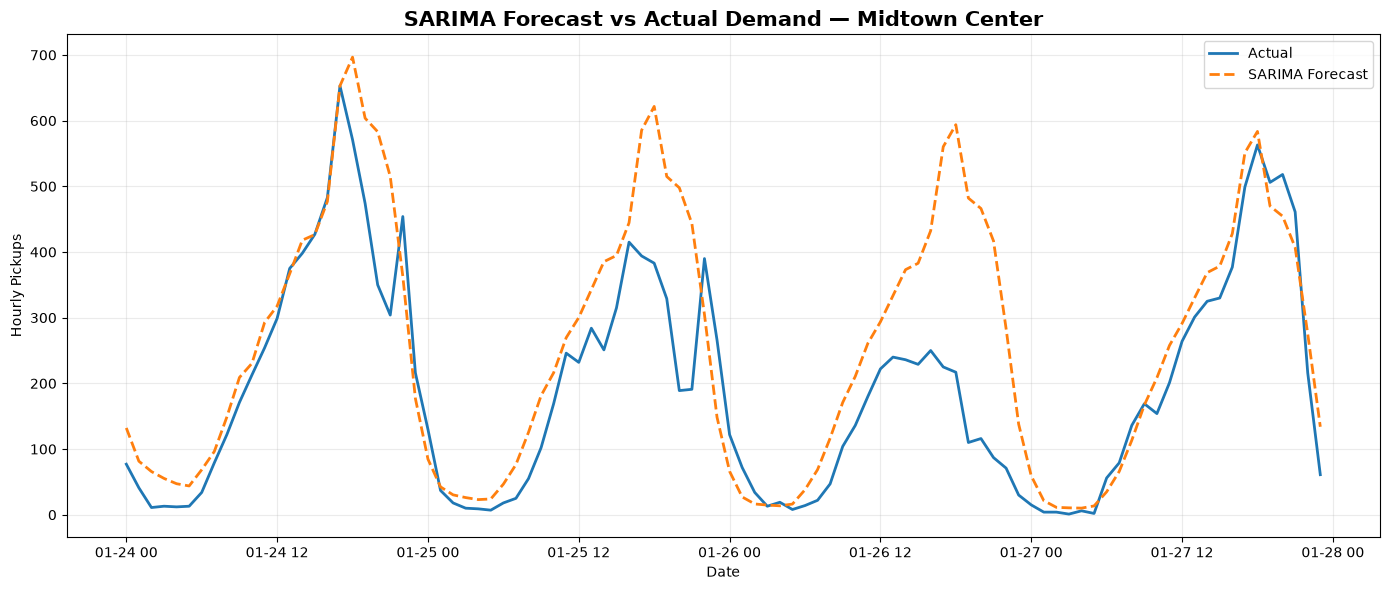

In [120]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    sarima_val.index,
    sarima_val["demand"],
    linewidth=2,
    label="Actual"
)

ax.plot(
    sarima_val.index,
    sarima_pred,
    linewidth=2,
    linestyle="--",
    label="SARIMA Forecast"
)

ax.set_title(
    "SARIMA Forecast vs Actual Demand — Midtown Center",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Pickups")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [121]:
zone161_val_mask = (
    val_df["PULocationID"] == 161
)

X_val_161 = X_val.loc[zone161_val_mask]
y_val_161 = y_val.loc[zone161_val_mask]

print("Zone 161 validation rows:", len(X_val_161))

Zone 161 validation rows: 96


In [122]:
extra_pred_161 = extra_model.predict(X_val_161)

extra161_mae = mean_absolute_error(
    y_val_161,
    extra_pred_161
)

extra161_rmse = np.sqrt(
    mean_squared_error(
        y_val_161,
        extra_pred_161
    )
)

extra161_r2 = r2_score(
    y_val_161,
    extra_pred_161
)

print(f"Extra Trees Zone 161 MAE : {extra161_mae:.3f}")
print(f"Extra Trees Zone 161 RMSE: {extra161_rmse:.3f}")
print(f"Extra Trees Zone 161 R²  : {extra161_r2:.3f}")

Extra Trees Zone 161 MAE : 35.901
Extra Trees Zone 161 RMSE: 57.182
Extra Trees Zone 161 R²  : 0.880


In [123]:
baseline_161 = val_df.loc[
    zone161_val_mask,
    "lag_24h"
]

baseline161_mae = mean_absolute_error(
    y_val_161,
    baseline_161
)

baseline161_rmse = np.sqrt(
    mean_squared_error(y_val_161, baseline_161)
)

baseline161_r2 = r2_score(
    y_val_161,
    baseline_161
)

print(f"Naive Zone 161 MAE : {baseline161_mae:.3f}")
print(f"Naive Zone 161 RMSE: {baseline161_rmse:.3f}")
print(f"Naive Zone 161 R²  : {baseline161_r2:.3f}")

Naive Zone 161 MAE : 93.115
Naive Zone 161 RMSE: 143.766
Naive Zone 161 R²  : 0.242


In [124]:
from prophet import Prophet

prophet_train = (
    sarima_train
    .reset_index()
    .rename(columns={
        "pickup_hour_timestamp": "ds",
        "demand": "y"
    })
)

prophet_train.head()

,ds,y
0,2025-01-01 00:00:00,274
1,2025-01-01 01:00:00,248
2,2025-01-01 02:00:00,150
3,2025-01-01 03:00:00,67
4,2025-01-01 04:00:00,33


In [125]:
import time

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)

start = time.time()

prophet_model.fit(prophet_train)

prophet_time = time.time() - start

print(f"Prophet training time: {prophet_time:.2f} seconds")

10:56:17 - cmdstanpy - INFO - Chain [1] start processing
10:56:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet training time: 3.64 seconds


In [126]:
future = pd.DataFrame({
    "ds": sarima_val.index
})

prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast["yhat"].values

In [127]:
prophet_mae = mean_absolute_error(
    sarima_val["demand"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        sarima_val["demand"],
        prophet_pred
    )
)

prophet_r2 = r2_score(
    sarima_val["demand"],
    prophet_pred
)

print(f"Prophet MAE : {prophet_mae:.3f}")
print(f"Prophet RMSE: {prophet_rmse:.3f}")
print(f"Prophet R²  : {prophet_r2:.3f}")

Prophet MAE : 69.213
Prophet RMSE: 96.195
Prophet R²  : 0.661


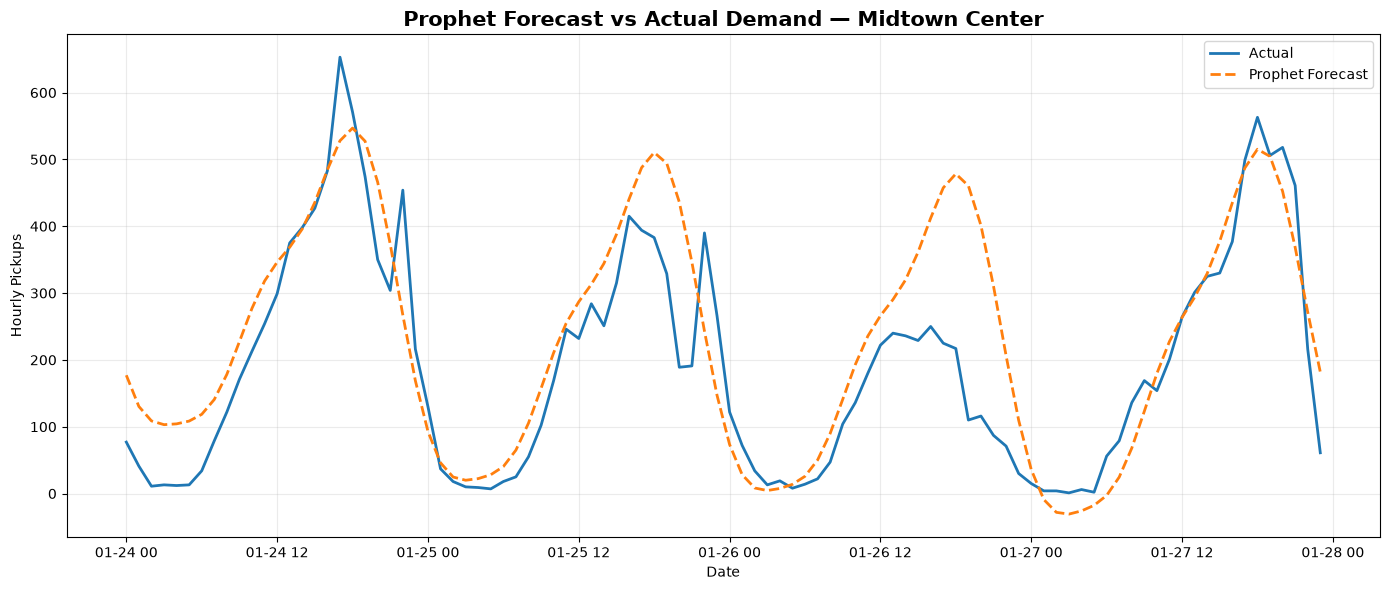

In [128]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    sarima_val.index,
    sarima_val["demand"],
    linewidth=2,
    label="Actual"
)

ax.plot(
    sarima_val.index,
    prophet_pred,
    linestyle="--",
    linewidth=2,
    label="Prophet Forecast"
)

ax.set_title(
    "Prophet Forecast vs Actual Demand — Midtown Center",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Pickups")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [129]:
zone161_results = pd.DataFrame({
    "Model": [
        "Naive 24h",
        "SARIMA",
        "Prophet",
        "Extra Trees"
    ],
    "MAE": [
        93.115,
        78.304,
        69.213,
        35.901
    ],
    "RMSE": [
        143.766,
        119.035,
        96.195,
        57.182
    ],
    "R2": [
        0.242,
        0.480,
        0.661,
        0.880
    ]
})

zone161_results

,Model,MAE,RMSE,R2
0,Naive 24h,93.115,143.766,0.242
1,SARIMA,78.304,119.035,0.480
2,Prophet,69.213,96.195,0.661
3,Extra Trees,35.901,57.182,0.880


In [130]:
zone161_results.to_csv(
    "artifacts/zone161_model_comparison.csv",
    index=False
)

print("Zone 161 comparison saved!")

Zone 161 comparison saved!


In [131]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_values = sarima_train[["demand"]].values
val_values = sarima_val[["demand"]].values

scaler.fit(train_values)

train_scaled = scaler.transform(train_values)
val_scaled = scaler.transform(val_values)

print(train_scaled.shape)
print(val_scaled.shape)

(552, 1)
(96, 1)


In [132]:
def create_sequences(data, lookback=24):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [133]:
LOOKBACK = 24

X_lstm_train, y_lstm_train = create_sequences(
    train_scaled,
    LOOKBACK
)

print("X train:", X_lstm_train.shape)
print("y train:", y_lstm_train.shape)

X train: (528, 24, 1)
y train: (528, 1)


In [134]:
validation_context = np.concatenate([
    train_scaled[-LOOKBACK:],
    val_scaled
])

X_lstm_val, y_lstm_val = create_sequences(
    validation_context,
    LOOKBACK
)

print("X validation:", X_lstm_val.shape)
print("y validation:", y_lstm_val.shape)

X validation: (96, 24, 1)
y validation: (96, 1)


In [135]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(
        32,
        input_shape=(LOOKBACK, 1)
    ),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

C:\Users\Harshith\anaconda3\envs\taxi\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

start = time.time()

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,

    validation_data=(
        X_lstm_val,
        y_lstm_val
    ),

    epochs=100,
    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

lstm_time = time.time() - start

print(f"\nLSTM training time: {lstm_time:.2f} seconds")

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0813 - val_loss: 0.0332
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0504 - val_loss: 0.0279
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0412 - val_loss: 0.0248
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0343 - val_loss: 0.0182
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0258 - val_loss: 0.0120
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0190 - val_loss: 0.0082
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0138 - val_loss: 0.0070
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0113 - val_loss: 0.0058
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0092 - val_loss: 0.0060
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0099 - val_loss: 0.0064
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0083 - val_loss: 0.0072
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

In [137]:
lstm_pred_scaled = lstm_model.predict(
    X_lstm_val
)

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

lstm_actual = scaler.inverse_transform(
    y_lstm_val
).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


In [138]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    lstm_actual,
    lstm_pred
)

print(f"LSTM MAE : {lstm_mae:.3f}")
print(f"LSTM RMSE: {lstm_rmse:.3f}")
print(f"LSTM R²  : {lstm_r2:.3f}")

LSTM MAE : 48.377
LSTM RMSE: 67.713
LSTM R²  : 0.832


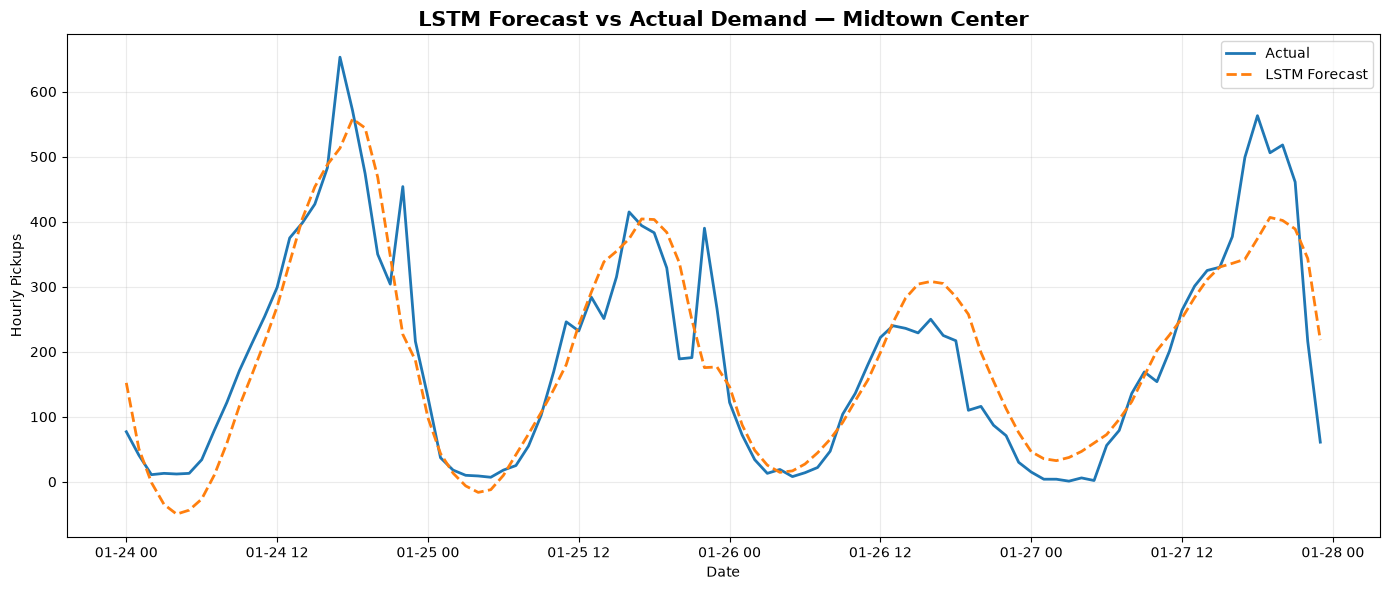

In [139]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    sarima_val.index,
    lstm_actual,
    linewidth=2,
    label="Actual"
)

ax.plot(
    sarima_val.index,
    lstm_pred,
    linestyle="--",
    linewidth=2,
    label="LSTM Forecast"
)

ax.set_title(
    "LSTM Forecast vs Actual Demand — Midtown Center",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Pickups")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [140]:
zone161_results = pd.DataFrame({
    "Model": [
        "Naive 24h",
        "SARIMA",
        "Prophet",
        "LSTM",
        "Extra Trees"
    ],
    "MAE": [
        93.115,
        78.304,
        69.213,
        48.377,
        35.901
    ],
    "RMSE": [
        143.766,
        119.035,
        96.195,
        67.713,
        57.182
    ],
    "R2": [
        0.242,
        0.480,
        0.661,
        0.832,
        0.880
    ]
})

zone161_results.to_csv(
    "artifacts/zone161_model_comparison.csv",
    index=False
)

zone161_results

,Model,MAE,RMSE,R2
0,Naive 24h,93.115,143.766,0.242
1,SARIMA,78.304,119.035,0.480
2,Prophet,69.213,96.195,0.661
3,LSTM,48.377,67.713,0.832
4,Extra Trees,35.901,57.182,0.880


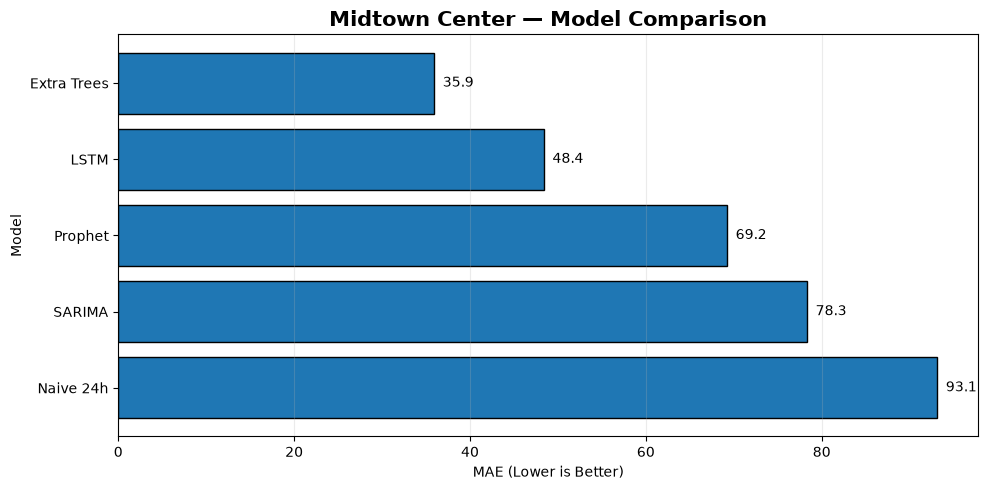

In [141]:
plot_zone = zone161_results.sort_values("MAE")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    plot_zone["Model"],
    plot_zone["MAE"],
    edgecolor="black"
)

ax.set_title(
    "Midtown Center — Model Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("MAE (Lower is Better)")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.25)

for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}",
        va="center"
    )

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [142]:
import optuna

print("Optuna version:", optuna.__version__)

Optuna version: 5.0.0


In [143]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error

def objective_extra(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 400
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 8, 30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 5
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", 0.7, 1.0]
        ),

        "n_jobs": -1,
        "random_state": 42
    }

    model = ExtraTreesRegressor(**params)

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    return mean_absolute_error(y_val, pred)

In [144]:
study_extra = optuna.create_study(
    direction="minimize"
)

study_extra.optimize(
    objective_extra,
    n_trials=20
)

[I 2026-09-20 11:13:33,594] A new study created in memory with name: no-name-2ab107f2-38e6-4916-909f-f7e0db8363b9
[I 2026-09-20 11:13:38,592] Trial 0 finished with value: 4.313993161186563 and parameters: {'n_estimators': 111, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 4.313993161186563.
[I 2026-09-20 11:13:41,715] Trial 1 finished with value: 4.54382051623715 and parameters: {'n_estimators': 129, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 4.313993161186563.
[I 2026-09-20 11:14:16,762] Trial 2 finished with value: 4.07182971206335 and parameters: {'n_estimators': 234, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 0.7}. Best is trial 2 with value: 4.07182971206335.
[I 2026-09-20 11:15:18,282] Trial 3 finished with value: 4.148108971033337 and parameters: {'n_estimators': 310, 'max_depth': 30, 'min_samples_sp

In [145]:
print("Best MAE:", study_extra.best_value)

print("\nBest parameters:")
for key, value in study_extra.best_params.items():
    print(f"{key}: {value}")

Best MAE: 4.053649257494391

Best parameters:
n_estimators: 223
max_depth: 16
min_samples_split: 2
min_samples_leaf: 2
max_features: 0.7


In [146]:
tuned_extra = ExtraTreesRegressor(
    n_estimators=223,
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=42
)

start = time.time()

tuned_extra.fit(X_train, y_train)

tuned_extra_pred = tuned_extra.predict(X_val)

tuned_extra_time = time.time() - start

tuned_extra_mae = mean_absolute_error(
    y_val, tuned_extra_pred
)

tuned_extra_rmse = np.sqrt(
    mean_squared_error(y_val, tuned_extra_pred)
)

tuned_extra_r2 = r2_score(
    y_val, tuned_extra_pred
)

print(f"Tuned Extra Trees MAE : {tuned_extra_mae:.3f}")
print(f"Tuned Extra Trees RMSE: {tuned_extra_rmse:.3f}")
print(f"Tuned Extra Trees R²  : {tuned_extra_r2:.3f}")
print(f"Training + prediction : {tuned_extra_time:.2f} seconds")

Tuned Extra Trees MAE : 4.054
Tuned Extra Trees RMSE: 12.955
Tuned Extra Trees R²  : 0.948
Training + prediction : 24.96 seconds


In [147]:
improvement = (
    (extra_mae - tuned_extra_mae)
    / extra_mae
) * 100

print(
    f"MAE improvement over untuned Extra Trees: "
    f"{improvement:.2f}%"
)

MAE improvement over untuned Extra Trees: 1.73%


In [148]:
from xgboost import XGBRegressor

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 150, 600
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 1.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-3, 10.0,
            log=True
        ),

        "objective": "reg:squarederror",
        "n_jobs": -1,
        "random_state": 42
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    return mean_absolute_error(y_val, pred)

In [149]:
study_xgb = optuna.create_study(
    direction="minimize"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=20
)

[I 2026-09-20 11:25:05,146] A new study created in memory with name: no-name-484db5da-0bf9-4161-9c35-9348cde90ffa
[I 2026-09-20 11:25:08,869] Trial 0 finished with value: 5.05980920791626 and parameters: {'n_estimators': 220, 'max_depth': 8, 'learning_rate': 0.01217834226134884, 'subsample': 0.7821312017192246, 'colsample_bytree': 0.834815056956022, 'min_child_weight': 10, 'reg_alpha': 0.06502465639357179, 'reg_lambda': 0.0014233005846420262}. Best is trial 0 with value: 5.05980920791626.
[I 2026-09-20 11:25:12,472] Trial 1 finished with value: 4.307372570037842 and parameters: {'n_estimators': 471, 'max_depth': 5, 'learning_rate': 0.03563776898214234, 'subsample': 0.9575292908746222, 'colsample_bytree': 0.6230289744107661, 'min_child_weight': 1, 'reg_alpha': 0.413886684758078, 'reg_lambda': 0.4264754123730801}. Best is trial 1 with value: 4.307372570037842.
[I 2026-09-20 11:25:16,535] Trial 2 finished with value: 4.29885196685791 and parameters: {'n_estimators': 391, 'max_depth': 7, '

In [150]:
print(f"Best XGBoost MAE: {study_xgb.best_value:.4f}")

print("\nBest parameters:")

for key, value in study_xgb.best_params.items():
    print(f"{key}: {value}")

Best XGBoost MAE: 4.2148

Best parameters:
n_estimators: 300
max_depth: 8
learning_rate: 0.022820981142691977
subsample: 0.7789362419014318
colsample_bytree: 0.7079645999144555
min_child_weight: 5
reg_alpha: 0.029034968071053012
reg_lambda: 6.457833593901761


In [151]:
tuned_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.022820981142691977,
    subsample=0.7789362419014318,
    colsample_bytree=0.7079645999144555,
    min_child_weight=5,
    reg_alpha=0.029034968071053012,
    reg_lambda=6.457833593901761,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

start = time.time()

tuned_xgb.fit(X_train, y_train)

tuned_xgb_pred = tuned_xgb.predict(X_val)

tuned_xgb_time = time.time() - start

tuned_xgb_mae = mean_absolute_error(
    y_val, tuned_xgb_pred
)

tuned_xgb_rmse = np.sqrt(
    mean_squared_error(y_val, tuned_xgb_pred)
)

tuned_xgb_r2 = r2_score(
    y_val, tuned_xgb_pred
)

print(f"Tuned XGBoost MAE : {tuned_xgb_mae:.3f}")
print(f"Tuned XGBoost RMSE: {tuned_xgb_rmse:.3f}")
print(f"Tuned XGBoost R²  : {tuned_xgb_r2:.3f}")
print(f"Training + prediction: {tuned_xgb_time:.2f} seconds")

Tuned XGBoost MAE : 4.215
Tuned XGBoost RMSE: 13.370
Tuned XGBoost R²  : 0.944
Training + prediction: 4.07 seconds


In [152]:
xgb_improvement = (
    (xgb_mae - tuned_xgb_mae)
    / xgb_mae
) * 100

print(
    f"MAE improvement over untuned XGBoost: "
    f"{xgb_improvement:.2f}%"
)

MAE improvement over untuned XGBoost: 1.39%


In [153]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 150, 600
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 15, 80
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 4, 12
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 60
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 1.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-3, 10.0,
            log=True
        ),

        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMRegressor(**params)

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    return mean_absolute_error(y_val, pred)

In [154]:
study_lgbm = optuna.create_study(
    direction="minimize"
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=20
)

[I 2026-09-20 11:30:19,172] A new study created in memory with name: no-name-8037c1bb-5eb9-4816-bce8-5c244026a6f4
[I 2026-09-20 11:30:22,037] Trial 0 finished with value: 4.428581890424521 and parameters: {'n_estimators': 434, 'learning_rate': 0.05539637028280564, 'num_leaves': 17, 'max_depth': 12, 'min_child_samples': 45, 'subsample': 0.7105895844169264, 'colsample_bytree': 0.9532335823270489, 'reg_alpha': 0.4541523336768032, 'reg_lambda': 5.106517999956928}. Best is trial 0 with value: 4.428581890424521.
[I 2026-09-20 11:30:26,627] Trial 1 finished with value: 4.361914650208807 and parameters: {'n_estimators': 565, 'learning_rate': 0.022598840262685032, 'num_leaves': 22, 'max_depth': 7, 'min_child_samples': 43, 'subsample': 0.6274520572655778, 'colsample_bytree': 0.8562093450730256, 'reg_alpha': 0.00019221312441820957, 'reg_lambda': 0.10474183962784894}. Best is trial 1 with value: 4.361914650208807.
[I 2026-09-20 11:30:32,730] Trial 2 finished with value: 4.3626497501406245 and para

In [155]:
print(
    f"Best LightGBM MAE: "
    f"{study_lgbm.best_value:.4f}"
)

print("\nBest parameters:")

for key, value in study_lgbm.best_params.items():
    print(f"{key}: {value}")

Best LightGBM MAE: 4.2174

Best parameters:
n_estimators: 573
learning_rate: 0.05902820505417626
num_leaves: 65
max_depth: 11
min_child_samples: 20
subsample: 0.7793043526853062
colsample_bytree: 0.6940259650507679
reg_alpha: 0.005313933931691587
reg_lambda: 0.0014149929730210011


In [156]:
tuned_lgbm = LGBMRegressor(
    n_estimators=573,
    learning_rate=0.05902820505417626,
    num_leaves=65,
    max_depth=11,
    min_child_samples=20,
    subsample=0.7793043526853062,
    colsample_bytree=0.6940259650507679,
    reg_alpha=0.005313933931691587,
    reg_lambda=0.0014149929730210011,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()

tuned_lgbm.fit(X_train, y_train)
tuned_lgbm_pred = tuned_lgbm.predict(X_val)

tuned_lgbm_time = time.time() - start

tuned_lgbm_mae = mean_absolute_error(
    y_val, tuned_lgbm_pred
)

tuned_lgbm_rmse = np.sqrt(
    mean_squared_error(y_val, tuned_lgbm_pred)
)

tuned_lgbm_r2 = r2_score(
    y_val, tuned_lgbm_pred
)

print(f"Tuned LightGBM MAE : {tuned_lgbm_mae:.3f}")
print(f"Tuned LightGBM RMSE: {tuned_lgbm_rmse:.3f}")
print(f"Tuned LightGBM R²  : {tuned_lgbm_r2:.3f}")
print(f"Training + prediction: {tuned_lgbm_time:.2f} seconds")

Tuned LightGBM MAE : 4.217
Tuned LightGBM RMSE: 13.380
Tuned LightGBM R²  : 0.944
Training + prediction: 4.77 seconds


In [157]:
lgbm_improvement = (
    (lgbm_mae - tuned_lgbm_mae)
    / lgbm_mae
) * 100

print(
    f"MAE improvement over untuned LightGBM: "
    f"{lgbm_improvement:.2f}%"
)

MAE improvement over untuned LightGBM: 3.52%


In [158]:
weather_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weather_code",
    "wind_speed_10m"
]

In [159]:
features_without_weather = [
    col for col in feature_columns
    if col not in weather_features
]

print("With weather   :", len(feature_columns))
print("Without weather:", len(features_without_weather))

print("\nRemoved:")
print(set(feature_columns) - set(features_without_weather))

With weather   : 22
Without weather: 15

Removed:
{'snowfall', 'rain', 'wind_speed_10m', 'precipitation', 'temperature_2m', 'weather_code', 'relative_humidity_2m'}


In [160]:
X_train_no_weather = train_df[
    features_without_weather
].copy()

X_val_no_weather = val_df[
    features_without_weather
].copy()

print(X_train_no_weather.shape)
print(X_val_no_weather.shape)

(100224, 15)
(25056, 15)


In [161]:
extra_no_weather = ExtraTreesRegressor(
    n_estimators=223,
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=42
)

start = time.time()

extra_no_weather.fit(
    X_train_no_weather,
    y_train
)

no_weather_pred = extra_no_weather.predict(
    X_val_no_weather
)

no_weather_time = time.time() - start

no_weather_mae = mean_absolute_error(
    y_val,
    no_weather_pred
)

no_weather_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        no_weather_pred
    )
)

no_weather_r2 = r2_score(
    y_val,
    no_weather_pred
)

print(f"No-weather MAE : {no_weather_mae:.3f}")
print(f"No-weather RMSE: {no_weather_rmse:.3f}")
print(f"No-weather R²  : {no_weather_r2:.3f}")
print(f"Training + prediction: {no_weather_time:.2f} seconds")

No-weather MAE : 4.055
No-weather RMSE: 12.983
No-weather R²  : 0.948
Training + prediction: 15.69 seconds


In [162]:
weather_mae_change = (
    (no_weather_mae - tuned_extra_mae)
    / no_weather_mae
) * 100

print(
    f"MAE improvement from adding weather: "
    f"{weather_mae_change:.2f}%"
)

MAE improvement from adding weather: 0.03%


In [163]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tuned_extra.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
16,lag_1h,0.260795
18,lag_168h,0.206552
17,lag_24h,0.180516
19,rolling_mean_3h,0.149579
20,rolling_mean_24h,0.089438
21,rolling_std_24h,0.070949
1,hour,0.009377
5,hour_sin,0.006738
6,hour_cos,0.006199
7,dow_sin,0.002763


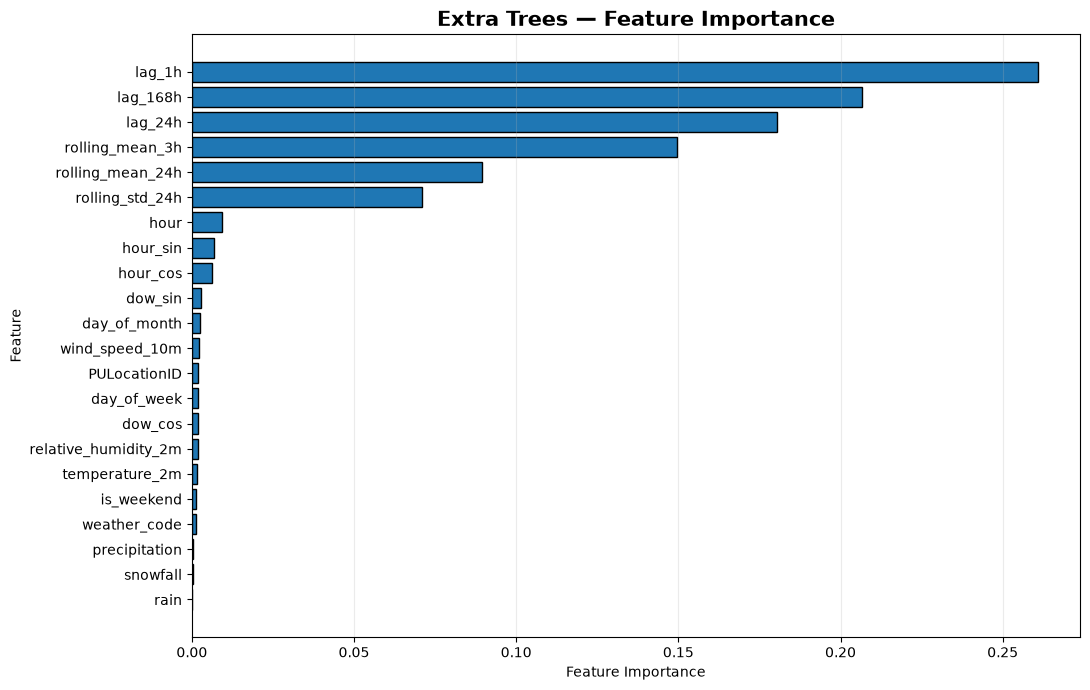

In [164]:
fig, ax = plt.subplots(figsize=(11, 7))

plot_imp = feature_importance.sort_values(
    "Importance",
    ascending=True
)

bars = ax.barh(
    plot_imp["Feature"],
    plot_imp["Importance"],
    edgecolor="black"
)

ax.set_title(
    "Extra Trees — Feature Importance",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
X_shap = X_val.sample(
    n=500,
    random_state=42
)

explainer = shap.TreeExplainer(tuned_extra)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

In [89]:
from sklearn.ensemble import ExtraTreesRegressor
import time

tuned_extra = ExtraTreesRegressor(
    n_estimators=223,
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=42
)

start = time.time()

tuned_extra.fit(X_train, y_train)

print(
    f"Tuned Extra Trees trained in "
    f"{time.time() - start:.2f} seconds"
)

Tuned Extra Trees trained in 16.92 seconds


In [90]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    tuned_extra,
    "artifacts/tuned_extra_trees.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [1]:
import joblib

tuned_extra = joblib.load(
    "artifacts/tuned_extra_trees.joblib"
)

print("Model loaded successfully")

Model loaded successfully


In [91]:
import shap
import time

X_shap = X_val.sample(
    n=200,
    random_state=42
)

start = time.time()

explainer = shap.TreeExplainer(tuned_extra)
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)
print(f"Time taken: {time.time() - start:.2f} seconds")

SHAP values shape: (200, 22)
Time taken: 140.33 seconds


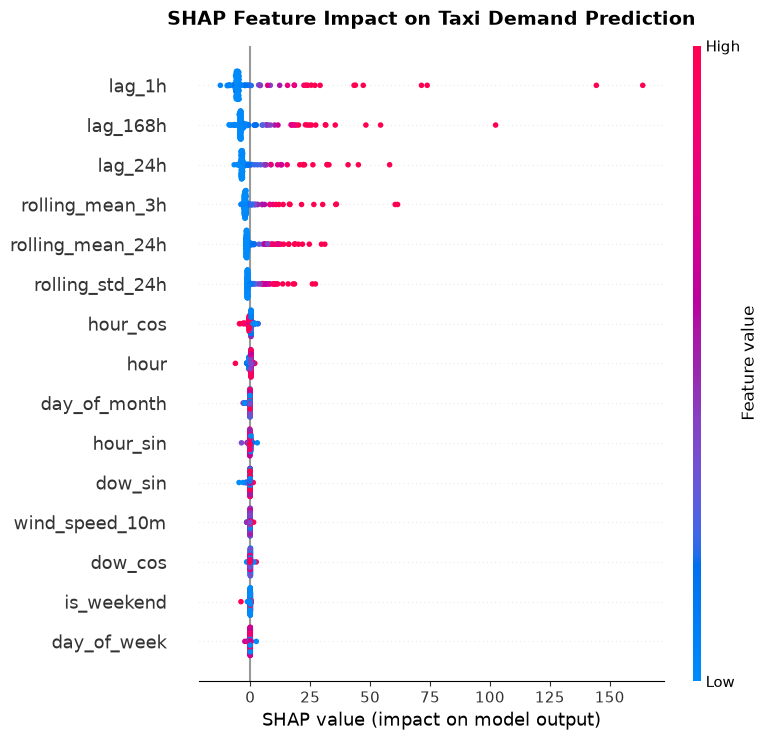

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Feature Impact on Taxi Demand Prediction",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

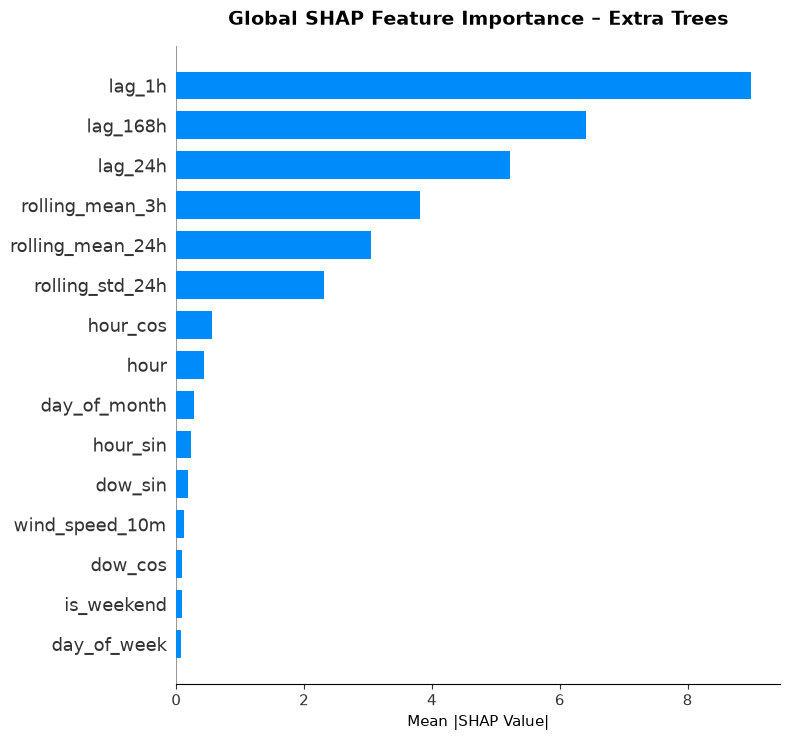

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Global SHAP Feature Importance – Extra Trees",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Mean |SHAP Value|", fontsize=11)
plt.tight_layout()
plt.show()

In [94]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions from tuned Extra Trees
val_predictions = tuned_extra.predict(X_val)

# Create dataframe for error analysis
error_df = val_df[
    ["pickup_hour_timestamp", "PULocationID", "Zone", "Borough", "demand", "hour"]
].copy()

error_df["prediction"] = val_predictions

# Residual: positive = model underpredicted
error_df["residual"] = error_df["demand"] - error_df["prediction"]

error_df["abs_error"] = np.abs(error_df["residual"])
error_df["squared_error"] = error_df["residual"] ** 2

print("Error dataframe shape:", error_df.shape)

print("\nValidation metrics:")
print("MAE :", mean_absolute_error(error_df["demand"], error_df["prediction"]))
print("RMSE:", np.sqrt(mean_squared_error(
    error_df["demand"], error_df["prediction"]
)))
print("R²  :", r2_score(error_df["demand"], error_df["prediction"]))

error_df.head()

Error dataframe shape: (25056, 10)

Validation metrics:
MAE : 4.053649257494391
RMSE: 12.954646525414399
R²  : 0.9477485301761224


,pickup_hour_timestamp,PULocationID,Zone,Borough,demand,hour,prediction,residual,abs_error,squared_error
552,2025-01-24 00:00:00,1,Newark Airport,EWR,0,0,0.290213,-0.290213,0.290213,0.084224
553,2025-01-24 01:00:00,1,Newark Airport,EWR,0,1,0.151193,-0.151193,0.151193,0.022859
554,2025-01-24 02:00:00,1,Newark Airport,EWR,0,2,0.148410,-0.148410,0.148410,0.022026
555,2025-01-24 03:00:00,1,Newark Airport,EWR,0,3,0.128939,-0.128939,0.128939,0.016625
556,2025-01-24 04:00:00,1,Newark Airport,EWR,0,4,0.193168,-0.193168,0.193168,0.037314


In [95]:
hour_error = (
    error_df.groupby("hour")
    .agg(
        MAE=("abs_error", "mean"),
        Mean_Demand=("demand", "mean"),
        Mean_Prediction=("prediction", "mean")
    )
    .reset_index()
)

hour_error.round(2)

,hour,MAE,Mean_Demand,Mean_Prediction
0,0,4.93,18.81,19.53
1,1,3.40,13.48,14.19
2,2,2.23,9.40,9.92
3,3,1.84,5.70,6.75
4,4,1.64,3.34,4.17
5,5,1.59,2.57,3.17
6,6,2.04,5.32,5.23
7,7,3.64,10.54,9.07
8,8,3.71,14.24,13.10
9,9,2.94,15.85,15.35


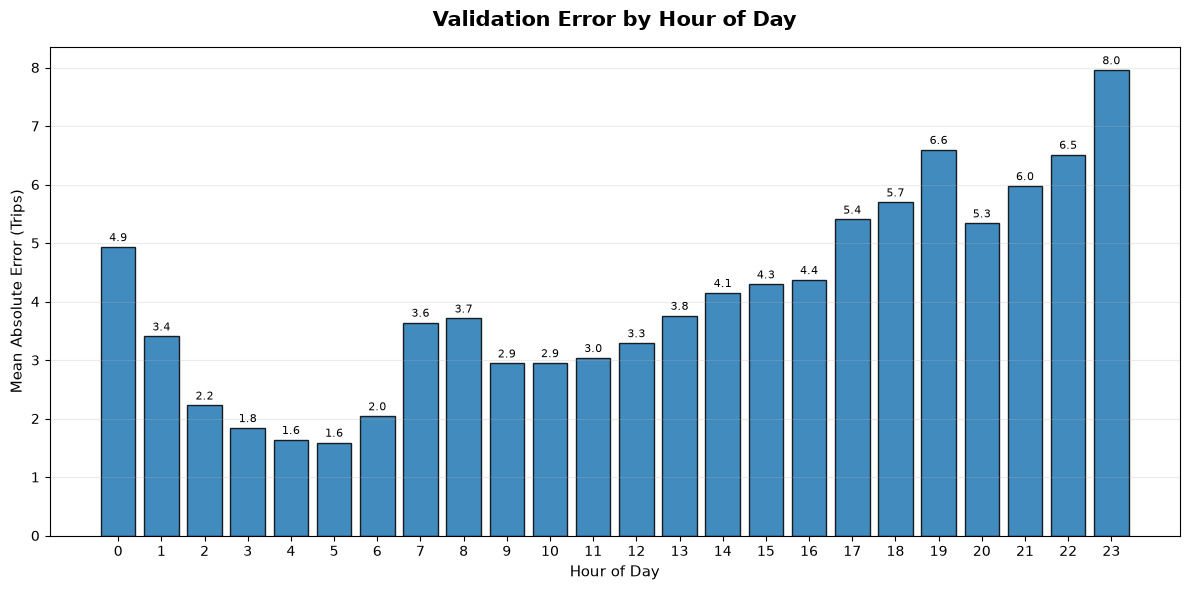

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    hour_error["hour"],
    hour_error["MAE"],
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Validation Error by Hour of Day",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Hour of Day", fontsize=11)
plt.ylabel("Mean Absolute Error (Trips)", fontsize=11)

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.25)

# Label each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.1f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [97]:
# Create demand ranges
error_df["demand_level"] = pd.cut(
    error_df["demand"],
    bins=[-1, 0, 10, 50, 150, float("inf")],
    labels=[
        "0",
        "1-10",
        "11-50",
        "51-150",
        ">150"
    ]
)

demand_error = (
    error_df.groupby(
        "demand_level",
        observed=True
    )
    .agg(
        Observations=("demand", "size"),
        Mean_Demand=("demand", "mean"),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

demand_error.round(2)

,demand_level,Observations,Mean_Demand,MAE
0,0,12406,0.00,0.53
1,1-10,8132,2.71,1.74
2,11-50,1985,24.43,8.79
3,51-150,1537,93.14,17.88
4,>150,996,249.00,36.07


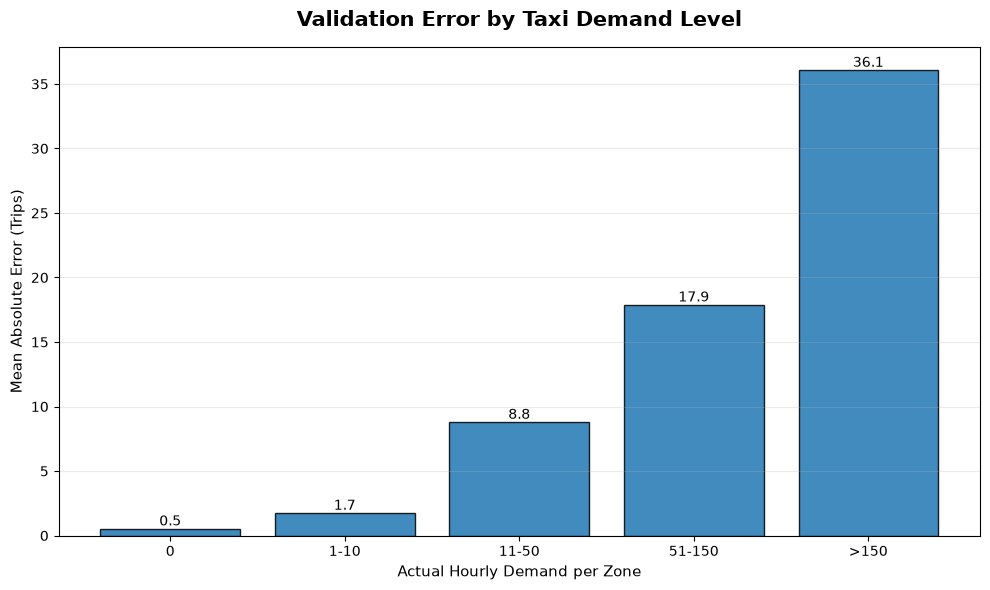

In [98]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    demand_error["demand_level"].astype(str),
    demand_error["MAE"],
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Validation Error by Taxi Demand Level",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Actual Hourly Demand per Zone", fontsize=11)
plt.ylabel("Mean Absolute Error (Trips)", fontsize=11)

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [99]:
zone_error = (
    error_df.groupby(
        ["PULocationID", "Zone", "Borough"],
        dropna=False
    )
    .agg(
        Observations=("demand", "size"),
        Mean_Demand=("demand", "mean"),
        Total_Demand=("demand", "sum"),
        MAE=("abs_error", "mean"),
        Total_Absolute_Error=("abs_error", "sum")
    )
    .reset_index()
)

# WAPE is more useful than MAPE because we have many zero-demand rows
zone_error["WAPE"] = (
    zone_error["Total_Absolute_Error"] /
    zone_error["Total_Demand"].replace(0, np.nan)
) * 100

top_zone_errors = (
    zone_error
    .sort_values("MAE", ascending=False)
    .head(15)
)

top_zone_errors[
    ["PULocationID", "Zone", "Borough",
     "Mean_Demand", "MAE", "WAPE"]
].round(2)

,PULocationID,Zone,Borough,Mean_Demand,MAE,WAPE
78,79,East Village,Manhattan,159.68,43.33,27.13
181,186,Penn Station/Madison Sq West,Manhattan,163.09,35.08,21.51
156,161,Midtown Center,Manhattan,193.34,34.09,17.63
127,132,JFK Airport,Queens,183.35,32.89,17.94
137,142,Lincoln Square East,Manhattan,153.60,30.24,19.69
133,138,LaGuardia Airport,Queens,112.55,29.69,26.38
244,249,West Village,Manhattan,137.18,29.58,21.56
241,246,West Chelsea/Hudson Yards,Manhattan,94.74,26.03,27.47
225,230,Times Sq/Theatre District,Manhattan,148.17,25.72,17.36
231,236,Upper East Side North,Manhattan,208.94,23.87,11.42


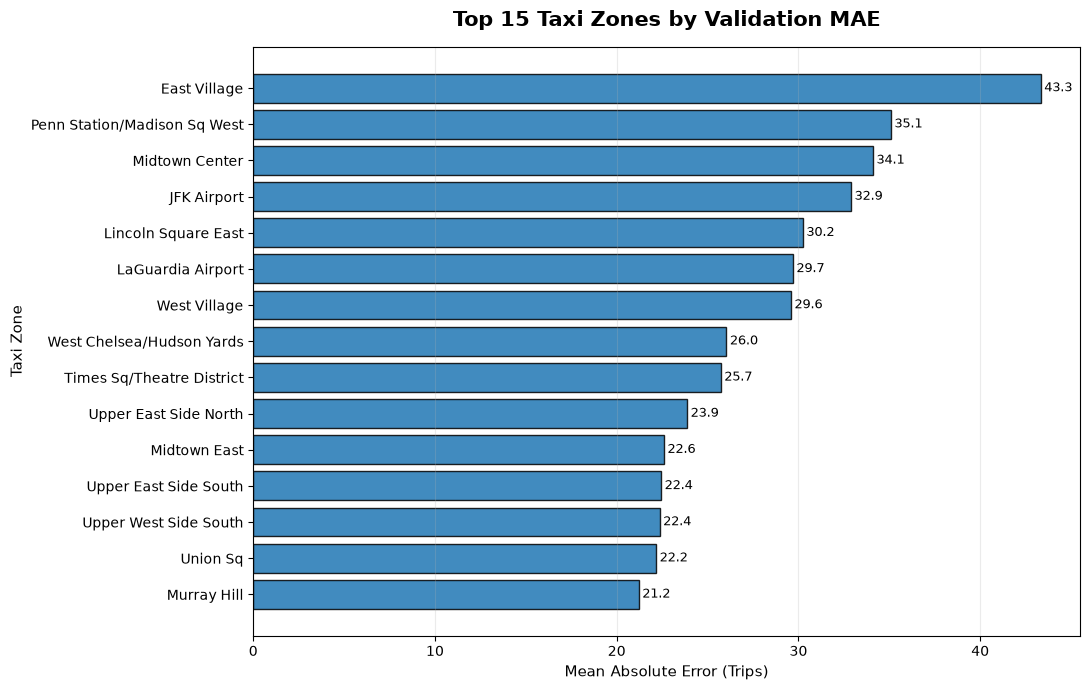

In [100]:
plot_data = top_zone_errors.sort_values("MAE")

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["Zone"],
    plot_data["MAE"],
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Top 15 Taxi Zones by Validation MAE",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Mean Absolute Error (Trips)", fontsize=11)
plt.ylabel("Taxi Zone", fontsize=11)

plt.grid(axis="x", alpha=0.25)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [101]:
worst_errors = (
    error_df
    .sort_values("abs_error", ascending=False)
    .head(20)
)

worst_errors[
    [
        "pickup_hour_timestamp",
        "PULocationID",
        "Zone",
        "Borough",
        "demand",
        "prediction",
        "residual",
        "abs_error"
    ]
].round(2)

C:\Users\Harshith\AppData\Local\Temp\ipykernel_17944\1442824228.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,pickup_hour_timestamp,PULocationID,Zone,Borough,demand,prediction,residual,abs_error
58607,2025-01-24 23:00:00,79,East Village,Manhattan,633,336.41,296.59,296.59
102525,2025-01-25 21:00:00,142,Lincoln Square East,Manhattan,567,304.80,262.20,262.20
58608,2025-01-25 00:00:00,79,East Village,Manhattan,847,622.62,224.38,224.38
116708,2025-01-27 20:00:00,161,Midtown Center,Manhattan,518,316.93,201.07,201.07
172495,2025-01-27 07:00:00,236,Upper East Side North,Manhattan,311,111.20,199.80,199.80
58633,2025-01-26 01:00:00,79,East Village,Manhattan,950,758.96,191.04,191.04
95107,2025-01-26 19:00:00,132,JFK Airport,Queens,419,229.55,189.45,189.45
135262,2025-01-25 22:00:00,186,Penn Station/Madison Sq West,Manhattan,386,201.59,184.41,184.41
172496,2025-01-27 08:00:00,236,Upper East Side North,Manhattan,402,224.61,177.39,177.39
135309,2025-01-27 21:00:00,186,Penn Station/Madison Sq West,Manhattan,362,185.22,176.78,176.78


In [102]:
high_demand_errors = error_df[
    error_df["demand"] > 150
].copy()

print("High-demand observations:", len(high_demand_errors))

print(
    "Average actual demand:",
    round(high_demand_errors["demand"].mean(), 2)
)

print(
    "Average prediction:",
    round(high_demand_errors["prediction"].mean(), 2)
)

print(
    "Average residual (Actual - Predicted):",
    round(high_demand_errors["residual"].mean(), 2)
)

underprediction_rate = (
    high_demand_errors["residual"] > 0
).mean() * 100

print(
    "High-demand underprediction rate:",
    round(underprediction_rate, 2),
    "%"
)

High-demand observations: 996
Average actual demand: 249.0
Average prediction: 233.05
Average residual (Actual - Predicted): 15.95
High-demand underprediction rate: 62.45 %


In [103]:
import pandas as pd

X_train_final = pd.concat(
    [X_train, X_val],
    axis=0
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
)

print("Final training X:", X_train_final.shape)
print("Final training y:", y_train_final.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Final training X: (125280, 22)
Final training y: (125280,)
Test X: (25056, 22)
Test y: (25056,)


In [104]:
from sklearn.ensemble import ExtraTreesRegressor
import time

final_model = ExtraTreesRegressor(
    n_estimators=223,
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=42
)

start = time.time()

final_model.fit(
    X_train_final,
    y_train_final
)

final_training_time = time.time() - start

print(
    f"Final model training time: "
    f"{final_training_time:.2f} seconds"
)

Final model training time: 29.80 seconds


In [105]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

test_predictions = final_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

print("FINAL TEST RESULTS")
print("------------------")
print(f"MAE : {test_mae:.3f}")
print(f"RMSE: {test_rmse:.3f}")
print(f"R²  : {test_r2:.3f}")

FINAL TEST RESULTS
------------------
MAE : 3.220
RMSE: 10.004
R²  : 0.974


In [106]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    final_model,
    "artifacts/final_extra_trees_model.joblib"
)

joblib.dump(
    feature_columns,
    "artifacts/feature_columns.joblib"
)

print("Final model saved successfully!")
print("Number of features:", len(feature_columns))

Final model saved successfully!
Number of features: 22


In [107]:
import json

model_metadata = {
    "model": "ExtraTreesRegressor",
    "forecast_horizon": "1 hour ahead",
    "n_features": len(feature_columns),
    "training_rows": len(X_train_final),
    "test_rows": len(X_test),

    "hyperparameters": {
        "n_estimators": 223,
        "max_depth": 16,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 0.7,
        "random_state": 42
    },

    "test_metrics": {
        "MAE": round(float(test_mae), 3),
        "RMSE": round(float(test_rmse), 3),
        "R2": round(float(test_r2), 3)
    }
}

with open(
    "artifacts/model_metadata.json",
    "w"
) as f:
    json.dump(model_metadata, f, indent=4)

print(model_metadata)

{'model': 'ExtraTreesRegressor', 'forecast_horizon': '1 hour ahead', 'n_features': 22, 'training_rows': 125280, 'test_rows': 25056, 'hyperparameters': {'n_estimators': 223, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'random_state': 42}, 'test_metrics': {'MAE': 3.22, 'RMSE': 10.004, 'R2': 0.974}}


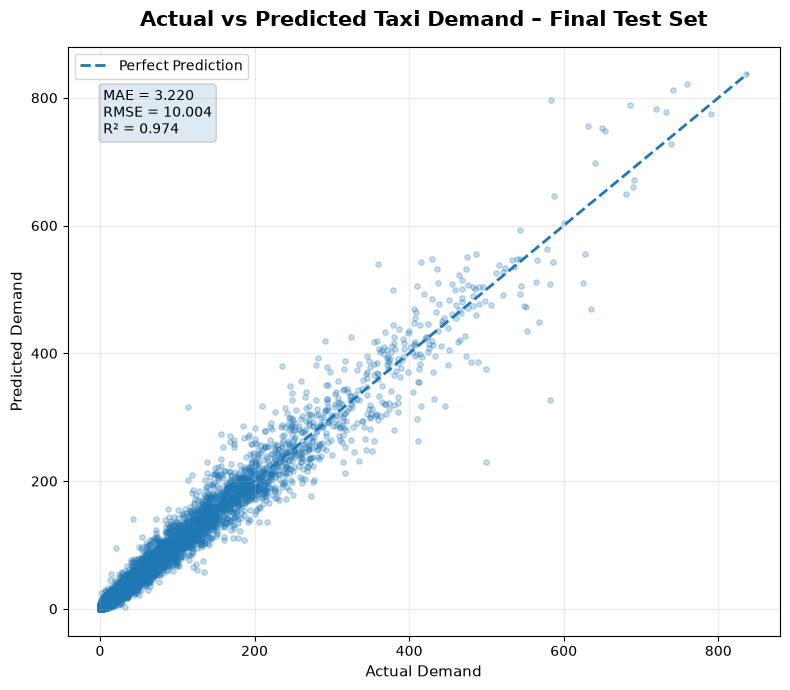

In [108]:
import matplotlib.pyplot as plt

# Compare actual and predicted demand
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.25,
    s=15
)

# Perfect prediction reference line
max_value = max(y_test.max(), test_predictions.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted Taxi Demand – Final Test Set",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Actual Demand", fontsize=11)
plt.ylabel("Predicted Demand", fontsize=11)

plt.grid(alpha=0.25)
plt.legend()

# Metrics box
metrics_text = (
    f"MAE = {test_mae:.3f}\n"
    f"RMSE = {test_rmse:.3f}\n"
    f"R² = {test_r2:.3f}"
)

plt.text(
    0.05,
    0.93,
    metrics_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()